# EDA — 강의 품질 분석

**데이터**: `data/processed/utterances_all.csv` (basic_eda.ipynb 실행 후 생성)  
**컬럼**: `lecture_id`, `date`, `timestamp`, `speaker_id`, `text_raw`, `text_clean`,
`sec_raw`, `sec_fixed`, `elapsed_sec`, `duration_sec`, `word_count`, `char_count`


## 1. Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

PROCESSED_DIR = Path('../data/processed')

# 도입부 기준 상수 (전 섹션 공통)
INTRO_SEC      = 30 * 60   # 도입부 정의: 항목 4 목표 안내·항목 5 복습 탐지
LLM_FILTER_SEC = 10 * 60   # LLM 입력 토큰 절감용 pre-filter (앞 10분만)

df = pd.read_csv(PROCESSED_DIR / 'utterances_all.csv')
summary = pd.read_csv(PROCESSED_DIR / 'lecture_summary.csv')

print(f'전체 발화 수: {len(df):,}행')
print(f'강의 수     : {df["lecture_id"].nunique()}개')
print(f'컬럼       : {list(df.columns)}')
df.head(3)


전체 발화 수: 22,756행
강의 수     : 15개
컬럼       : ['lecture_id', 'date', 'timestamp', 'speaker_id', 'text_raw', 'text_clean', 'sec_raw', 'sec_fixed', 'elapsed_sec', 'duration_sec', 'word_count', 'char_count']


,lecture_id,date,timestamp,speaker_id,text_raw,text_clean,sec_raw,sec_fixed,elapsed_sec,duration_sec,word_count,char_count
0,2026-02-02_kdt-backendj-21th,2026-02-02,09:11:17,b54f46b0,여러분 오늘 수업 진행하도록 하겠습니다. 저희가 이제 오늘 1차 잡바 마지막 날입니...,여러분 오늘 수업 진행하도록 하겠습니다. 저희가 이제 오늘 1차 잡바 마지막 날입니...,33077,33077,0,0,13,40
1,2026-02-02_kdt-backendj-21th,2026-02-02,09:11:17,b54f46b0,지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 ...,지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 ...,33077,33077,0,1,22,65
2,2026-02-02_kdt-backendj-21th,2026-02-02,09:11:18,b54f46b0,"NIO 패키지가 있고 그 다음에 NIO2라는 패키지를 가지고 있는데, 이 NI2는 ...","NIO 패키지가 있고 그 다음에 NIO2라는 패키지를 가지고 있는데, 이 NI2는 ...",33078,33078,1,15,28,83


## 2. 강의별 요약


In [2]:
display(summary)

,lecture_id,date,utterance_count,total_min,total_words,avg_word_count,avg_duration_sec,speaker_count
0,2026-02-02_kdt-backendj-21th,2026-02-02,1484,419.4,20449,13.8,17.0,1
1,2026-02-03_kdt-backendj-21th,2026-02-03,1860,519.6,24747,13.3,16.8,2
2,2026-02-04_kdt-backendj-21th,2026-02-04,1771,519.9,23424,13.2,17.6,1
3,2026-02-05_kdt-backendj-21th,2026-02-05,1656,518.6,21738,13.1,18.8,3
4,2026-02-06_kdt-backendj-21th,2026-02-06,1671,404.7,22095,13.2,14.5,1
5,2026-02-09_kdt-backendj-21th,2026-02-09,1555,420.4,21571,13.9,16.2,1
6,2026-02-10_kdt-backendj-21th,2026-02-10,1672,520.4,23124,13.8,18.7,1
7,2026-02-11_kdt-backendj-21th,2026-02-11,1560,520.1,20614,13.2,20.0,1
8,2026-02-12_kdt-backendj-21th,2026-02-12,986,267.0,12642,12.8,16.2,2
9,2026-02-13_kdt-backendj-21th,2026-02-13,1543,519.8,20691,13.4,20.2,2


## 3. 발화 길이 분포

**목적**: `word_count` 분포 → 짧은 노이즈 발화 비율 확인  
**결정 사항**: `filter_noise(min_words=?)` 파라미터 근거


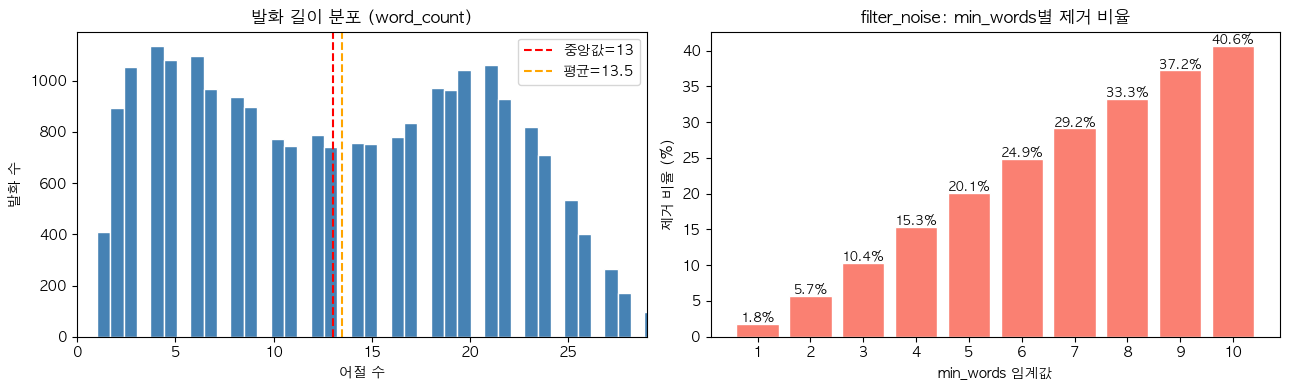

총 발화: 22,756  |  1어절 이하: 410건 (1.8%)
2어절 이하: 1,302건 (5.7%)
중앙값=13  평균=13.5  Q3=20  max=35


In [3]:
wc = df['word_count']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 히스토그램
axes[0].hist(wc, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(wc.median(), color='red',    linestyle='--', label=f'중앙값={wc.median():.0f}')
axes[0].axvline(wc.mean(),   color='orange', linestyle='--', label=f'평균={wc.mean():.1f}')
axes[0].set_xlim(0, wc.quantile(0.99))
axes[0].set_xlabel('어절 수')
axes[0].set_ylabel('발화 수')
axes[0].set_title('발화 길이 분포 (word_count)')
axes[0].legend()

# min_words 임계값별 제거 비율
thresholds = range(1, 11)
cut_ratios = [(wc <= t).mean() * 100 for t in thresholds]
axes[1].bar([str(t) for t in thresholds], cut_ratios, color='salmon', edgecolor='white')
axes[1].set_xlabel('min_words 임계값')
axes[1].set_ylabel('제거 비율 (%)')
axes[1].set_title('filter_noise: min_words별 제거 비율')
for i, v in enumerate(cut_ratios):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'총 발화: {len(wc):,}  |  1어절 이하: {(wc<=1).sum():,}건 ({(wc<=1).mean()*100:.1f}%)')
print(f'2어절 이하: {(wc<=2).sum():,}건 ({(wc<=2).mean()*100:.1f}%)')
print(f'중앙값={wc.median():.0f}  평균={wc.mean():.1f}  Q3={wc.quantile(0.75):.0f}  max={wc.max()}')


In [4]:
df[df['word_count']<= 2][['text_raw']].head(10)

,text_raw
25,됐을까요?
39,되셨어요.
41,파일 공유하겠습니다.
68,라이브러리 있죠.
73,아 목요일입니까?
77,프레임워크라든지큐멘테이션이라든지.
120,됐을까요? 그래서
133,붙여보십시오. 얘는
138,키보드로 탈출하세요.
196,하시면 된다.


**EDA 결과 — 발화 길이**

EDA 결과, word_count는 중앙값 13어절·평균 13.5어절로 나왔고, 1어절 이하는 1.8%, 2어절 이하는 5.7%에 불과했다.

짧은 발화 비율이 낮고, 2어절 이하 샘플을 직접 확인한 결과 모두 의미 있는 발화(STT 분절 특성상 끊긴 조각)였다. 노이즈로 볼 만한 빈 발화·감탄사 단독 발화는 거의 없었다.

따라서 짧은 발화 제거(filter_noise)는 적용하지 않는 것이 좋겠다. 대신 끊긴 발화를 어떻게 묶을지는 별도로 검토한다(→ merge_utterances).

## 4. 발화 간 간격 분포 (duration_sec)

**목적**: 이상 gap(쉬는 시간 등) 파악 + `merge_utterances(gap_sec=?)` 파라미터 근거


In [5]:
df['duration_sec']

0           0
1           1
2          15
3          12
4          12
         ... 
22751       2
22752       1
22753       3
22754    7098
22755       0
Name: duration_sec, Length: 22756, dtype: int64

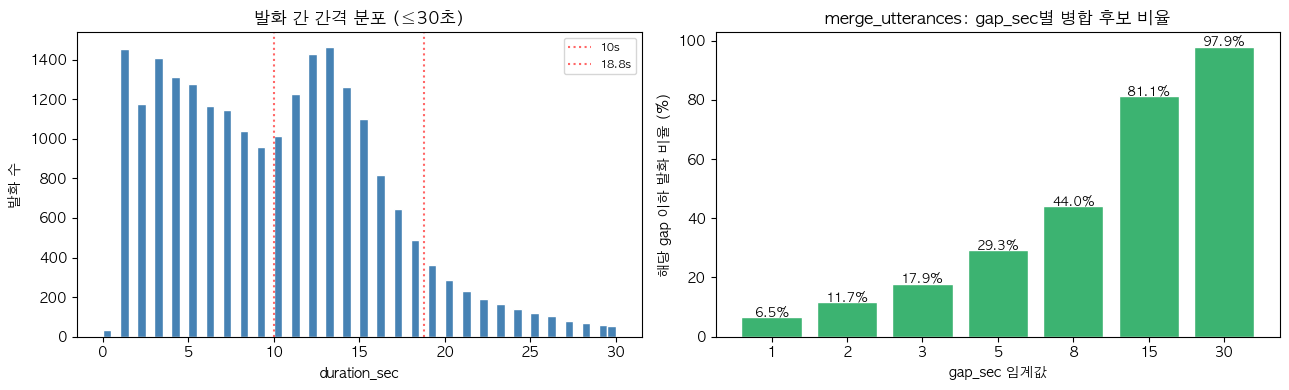

duration_sec  |  중앙값=10.0초  평균=18.8초
10분 초과 (쉬는 시간 후보): 55건
5분 초과: 57건


In [6]:
dur = df['duration_sec'].clip(upper=300)  # 5분 초과는 시각화에서 제외

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(dur[dur <= 30], bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('duration_sec')
axes[0].set_ylabel('발화 수')
axes[0].set_title('발화 간 간격 분포 (≤30초)')
for x in [10, 18.8]: # 중앙값, 평균
    axes[0].axvline(x, color='red', linestyle=':', alpha=0.6, label=f'{x}s')
axes[0].legend(fontsize=8)

# gap 임계값별 '병합 대상' 비율
gaps = [1, 2, 3, 5, 8, 15, 30]
merge_ratios = [(df['duration_sec'] <= g).mean() * 100 for g in gaps]
axes[1].bar([str(g) for g in gaps], merge_ratios, color='mediumseagreen', edgecolor='white')
axes[1].set_xlabel('gap_sec 임계값')
axes[1].set_ylabel('해당 gap 이하 발화 비율 (%)')
axes[1].set_title('merge_utterances: gap_sec별 병합 후보 비율')
for i, v in enumerate(merge_ratios):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'duration_sec  |  중앙값={df["duration_sec"].median():.1f}초  평균={df["duration_sec"].mean():.1f}초')
print(f'10분 초과 (쉬는 시간 후보): {(df["duration_sec"] > 60 * 10).sum()}건')
print(f'5분 초과: {(df["duration_sec"] > 300).sum()}건')


In [7]:
# 3~5초 gap 발화 샘플 — 앞뒤 발화 포함해서 전체 텍스트 확인
import random
random.seed(42)

mask = (df['duration_sec'] >= 3) & (df['duration_sec'] <= 5)
candidates = df[mask].index.tolist()
samples = random.sample(candidates, min(15, len(candidates)))

for idx in sorted(samples):
    row  = df.loc[idx]
    prev = df.loc[idx - 1] if idx > 0 else None
    nxt  = df.loc[idx + 1] if idx + 1 < len(df) else None

    print(f"idx={idx}  gap={row['duration_sec']}초  [{row['lecture_id']}]")
    if prev is not None:
        print(f"  이전: {prev['text_raw']}")
    print(f"  >>> : {row['text_raw']}")
    if nxt is not None:
        print(f"  다음: {nxt['text_raw']}")
    print()


idx=670  gap=4초  [2026-02-02_kdt-backendj-21th]
  이전: 또 가면 여러분들은 알고 있으니까 크리에이트하고 덮어쓰기 뭐 하는 트렁크리이트젝팅을 사용하셔도 상관없어요.
  >>> : 저는 한번 도움말 더 가서 보여드릴게요.
  다음: 여기에 패스의 라이트 스트링이죠.

idx=2123  gap=5초  [2026-02-03_kdt-backendj-21th]
  이전: 파일 이만큼 들어있어 뭔지는 모르겠지만, 들어가요 여기에 대충 봐도 여기 8천명들 아니야.
  >>> : 문자 캐릭터 셋 있고 컬처명들이 있으니까 타임존이라던지 아니면 국가번호 있으니까 문자셋 정보 이런 것들이 있고 여기 안에 뭐가 들어가 있냐면
  다음: 저희 샘플 파일도 여기 들어가 있어요. 샘플

idx=2540  gap=5초  [2026-02-03_kdt-backendj-21th]
  이전: 때 이 에러 로그를 열어서 보여주시면 돼 왜 여기 설정 오류가 들어있 어느 정도 설정을 했는지 안 했는지 장애가 났어 그럼 제일 먼저 에러 로고를 열어봐.
  >>> : 그 다음에 제너럴 로고는 그냥 우리가 알고 있기에 그냥 일반 공용 로그잖아요.
  다음: 여기 클라이언트가 다 접속한 기록을 가지고 있어요.

idx=2722  gap=5초  [2026-02-03_kdt-backendj-21th]
  이전: 그래서 여기가 지금 소문자로 나와 있고 나는 대문자로 지금 명령을 줘도 된다.
  >>> : 그기서 살짝 준다.
  다음: 이게 지금 셀렉트인데 얘네는 지금 셀렉트라는 것이 그냥 프린트 F랑 똑같은 거야.

idx=3333  gap=5초  [2026-02-03_kdt-backendj-21th]
  이전: 투표 한번 해보도록 하겠습니다. 프로그램 설치
  >>> : 안 되신 분들 체크하는 거니까 되신 분들은 공 안되신 분들은 X 편하게 투표하시고 C로 가시면 돼요.
  다음: 두 분 두 분만 지금 만드시는 거예요.

idx=5019  gap=5초  [2026-02-0

**EDA 결과 — 인접 발화 병합(merge_utterances) 검토**

EDA 결과, gap_sec 임계값별 병합 후보 비율을 보니 3초 이하 gap이 다수를 차지했다.

이를 분석해 보면, 짧은 발화일수록 다음 발화까지의 gap이 자연히 작아진다. 즉 gap이 작다고 병합하면 의미 단위가 아니라 단지 빠르게 이어진 발화를 인위적으로 합치게 되어 오히려 의미가 왜곡된다.

따라서 gap 기반 merge_utterances는 적용하지 않는 것이 좋겠다. 발화 묶음은 gap이 아니라 **쉬는 시간 단위 블록 분리 + kss 문장 분리**로 처리하는 방향으로 정한다(→ 섹션 7).

In [8]:
# duration_sec > 10분 발화 앞뒤 1개씩 출력
LONG_GAP_SEC = 60 * 10

for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    long_gaps = g[g['duration_sec'] > LONG_GAP_SEC].index.tolist()
    if not long_gaps:
        continue

    print(f"{'='*70}")
    print(f"[{lid}]  {len(long_gaps)}건")

    for idx in long_gaps:
        lo = max(0, idx - 1)
        hi = min(len(g) - 1, idx + 1)
        print(f"  ── gap={g.loc[idx, 'duration_sec']}초 (idx={idx}) ──")
        for i, row in g.loc[lo:hi].iterrows():
            marker = '>>>' if i == idx else '   '
            e = f"{row['speaker_id']} - {int(row['elapsed_sec']//60):02d}:{int(row['elapsed_sec']%60):02d}"
            print(f"  {marker} [{e}] {row['text_clean'][:70]}")
        print()


[2026-02-02_kdt-backendj-21th]  4건
  ── gap=3903초 (idx=543) ──
      [b54f46b0 - 91:44] 저희 쉬었다가 이거를 트라이 리소스로 바꾼 다음에풋에서 버트 타입으로 변환하는 것까지 하고 그런 식으로 진행을 하도록 하겠습니
  >>> [b54f46b0 - 91:51] 11시 43분이에요. 11시
      [b54f46b0 - 156:54] 그렇지 이거는 이제 만들어서 준 코드라서 내 걸로 되려고 그러면 10번은 안 보고 써야 되니까.

  ── gap=4324초 (idx=547) ──
      [b54f46b0 - 157:08] 되지 않을까 싶어요.
  >>> [b54f46b0 - 157:09] 되셨어요.
      [b54f46b0 - 229:13] 자 수업 진행하도 수업 시작하 저희가 이제 오전에 I이O 객체를 이용을 해서 파일의 객체 그 다음에 비트 비더 라이트프 스트림

  ── gap=1235초 (idx=1184) ──
      [b54f46b0 - 339:08] 2시 50분이니까.
  >>> [b54f46b0 - 339:08] 3시 10분에 오겠습니다.
      [b54f46b0 - 359:43] 여행하도록 하겠습니다.

  ── gap=685초 (idx=1480) ──
      [b54f46b0 - 407:15] 강사님 저 예전에 8버전 있어요. 하시는
  >>> [b54f46b0 - 407:17] 분들은 괜찮아 8버전 있어요.
      [b54f46b0 - 418:42] MSI 인 컬러를 하고 다음에 얘가 컨패그레이터라는 게 뜨죠 컨패그레이터라고 뜨면 거기 마S큐L 서버 인스톨레이션 지금 수할 

[2026-02-03_kdt-backendj-21th]  5건
  ── gap=710초 (idx=132) ──
      [b8c55a6e - 17:49] 오트리베투스를 통해서 반드시 봐야 되는 그런 상황이 조금 얘네들은 편하지만 어쩔 수 없는 불편하지만 어쩔 수 없는 그냥
  >>

**EDA 결과 — 발화 간 간격(duration_sec)과 쉬는 시간**

EDA 결과, duration_sec은 중앙값 10초·평균 18.8초로 대부분 짧았고, 10분(600초) 초과가 55건, 1시간 초과가 27건이었다.

큰 gap의 정체를 앞뒤 발화로 확인해 보니 쉬는 시간·점심·실습 대기·설치 대기가 섞여 있었다. 단순 gap 임계값만으로는 "쉬는 시간"과 "실습 대기"를 구분하지 못했고, 강사마다 break 길이가 달라 고정 임계값의 일반화도 어려웠다.

**확인하지 못한 것**: 임계값을 강사 전반에 일반화할 수 있는지는 단일 강사 데이터뿐이라 검증할 수 없었다 → 다강사 데이터 확보 후 재튜닝이 필요하다.

따라서 break는 "10분 이상 gap + 직전 발화에 쉬는 시간 키워드 동시 충족", 그리고 1시간 이상 gap은 무조건 break로 보는 기준이 좋겠다.

## 5. 구간 비율 확인 (intro / middle / outro)

**목적**: `intro_minutes=30`, `outro_minutes=15` 적절성 검증


,lecture_id,total_min,intro_pct,middle_pct,outro_pct,intro_end_min,outro_start_min
0,2026-02-02_kdt-backendj-21th,419.4,13.7,85.0,1.3,29.5,404.4
1,2026-02-03_kdt-backendj-21th,519.6,7.2,92.6,0.2,29.9,519.3
2,2026-02-04_kdt-backendj-21th,519.9,13.3,86.7,0.1,30.0,519.9
3,2026-02-05_kdt-backendj-21th,518.6,13.3,86.6,0.1,29.9,518.4
4,2026-02-06_kdt-backendj-21th,404.7,12.1,82.4,5.4,29.9,389.8
5,2026-02-09_kdt-backendj-21th,420.4,11.5,83.3,5.2,29.8,405.5
6,2026-02-10_kdt-backendj-21th,520.4,10.6,88.9,0.4,30.0,519.6
7,2026-02-11_kdt-backendj-21th,520.1,13.0,86.9,0.1,29.9,519.9
8,2026-02-12_kdt-backendj-21th,267.0,21.0,69.6,9.4,29.9,252.2
9,2026-02-13_kdt-backendj-21th,519.8,11.8,87.9,0.3,30.0,519.4


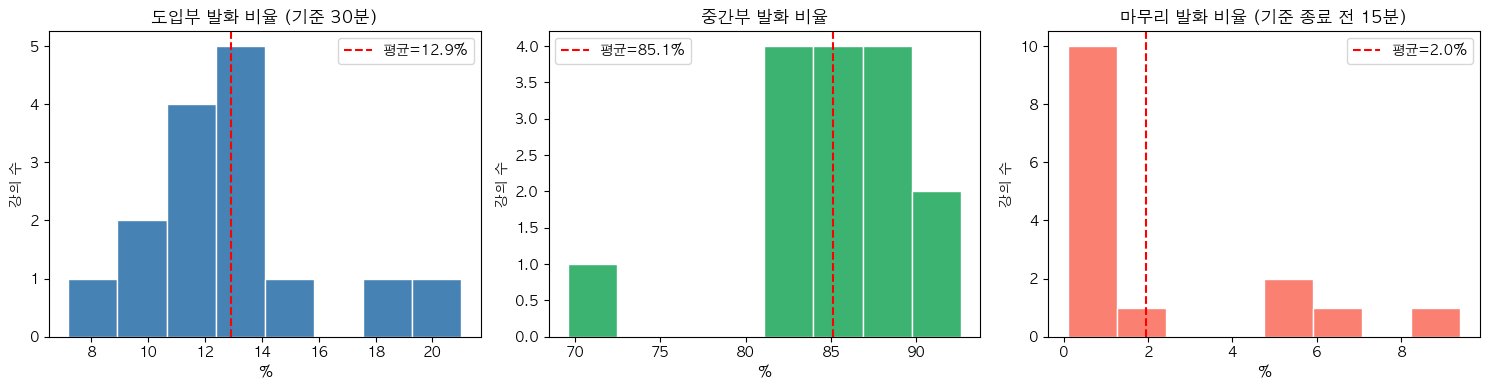


도입부 끝 시점(분): 평균=29.9  중앙값=29.9  min=29.5  max=30.0
마무리 시작 시점(분): 평균=469.5  중앙값=519.3


In [9]:
INTRO_MIN = 30
OUTRO_MIN = 15

records = []
for lid, g in df.groupby('lecture_id'):
    total_sec  = g['elapsed_sec'].max()
    intro_mask = g['elapsed_sec'] <= INTRO_MIN * 60
    outro_mask = g['elapsed_sec'] >= (total_sec - OUTRO_MIN * 60)
    mid_mask   = ~intro_mask & ~outro_mask
    records.append({
        'lecture_id':      lid,
        'total_min':       round(total_sec / 60, 1),
        'intro_pct':       round(intro_mask.mean() * 100, 1),
        'middle_pct':      round(mid_mask.mean()   * 100, 1),
        'outro_pct':       round(outro_mask.mean() * 100, 1),
        'intro_end_min':   round(g.loc[intro_mask, 'elapsed_sec'].max() / 60, 1) if intro_mask.any() else 0,
        'outro_start_min': round(g.loc[outro_mask, 'elapsed_sec'].min() / 60, 1) if outro_mask.any() else 0,
    })

seg_df = pd.DataFrame(records)
display(seg_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in [
    (axes[0], 'intro_pct',  f'도입부 발화 비율 (기준 {INTRO_MIN}분)',         'steelblue'),
    (axes[1], 'middle_pct', '중간부 발화 비율',                              'mediumseagreen'),
    (axes[2], 'outro_pct',  f'마무리 발화 비율 (기준 종료 전 {OUTRO_MIN}분)', 'salmon'),
]:
    ax.hist(seg_df[col], bins=8, color=color, edgecolor='white')
    ax.axvline(seg_df[col].mean(), color='red', linestyle='--',
               label=f'평균={seg_df[col].mean():.1f}%')
    ax.set_xlabel('%'); ax.set_ylabel('강의 수'); ax.set_title(title); ax.legend()

plt.tight_layout()
plt.show()

print(f'\n도입부 끝 시점(분): 평균={seg_df["intro_end_min"].mean():.1f}  '
      f'중앙값={seg_df["intro_end_min"].median():.1f}  '
      f'min={seg_df["intro_end_min"].min():.1f}  max={seg_df["intro_end_min"].max():.1f}')
print(f'마무리 시작 시점(분): 평균={seg_df["outro_start_min"].mean():.1f}  '
      f'중앙값={seg_df["outro_start_min"].median():.1f}')


**EDA 결과 — 구간 비율 (intro / middle / outro)**

EDA 결과, 총 강의 길이는 평균 475분(267~520분)이었고, 도입부 30분 기준 발화 비율은 평균 12.9%(최소 7.2%, 최대 21.0%), 중간부 85.1%, 마무리 15분 2.0%로 나왔다.

| 구간 | 기준 | 평균 비율 |
|------|------|----------|
| intro | 0~30분 | 12.9% |
| middle | 30분~종료-15분 | 85.1% |
| outro | 종료 전 15분 | 2.0% |

도입부 30분이 전체 발화의 약 13%를 담고 있어 학습 목표·전날 복습 안내를 포착하기에 충분한 분량이다. 반면 마무리 15분은 발화 비율이 2%로 매우 낮아, 대부분 종강 인사·저장 안내에 그쳤다.

따라서 항목 4(학습 목표)·항목 5(복습)는 **도입부 30분 윈도우**를 기준으로 삼는 것이 좋겠다. outro는 발화량이 적어 별도 항목 분석에서 비중을 낮게 두는 편이 합리적이다.

## 6. 화자 분석 (speaker_id)

**목적**: speaker_id 변경 패턴 확인 → 모두 동일 강사인지 검증  
speaker_id 변경 지점 앞뒤 5개 발화 출력


In [10]:
# 강의별 speaker_id 현황
spk_stats = (
    df.groupby('lecture_id')['speaker_id']
    .agg(speaker_count='nunique', top_speaker=lambda s: s.value_counts().index[0])
    .reset_index()
)
print(f'speaker_id 1개 강의: {(spk_stats["speaker_count"]==1).sum()}개')
print(f'speaker_id 2개 이상: {(spk_stats["speaker_count"]>1).sum()}개')
display(spk_stats)


speaker_id 1개 강의: 9개
speaker_id 2개 이상: 6개


,lecture_id,speaker_count,top_speaker
0,2026-02-02_kdt-backendj-21th,1,b54f46b0
1,2026-02-03_kdt-backendj-21th,2,b8c55a6e
2,2026-02-04_kdt-backendj-21th,1,23033da8
3,2026-02-05_kdt-backendj-21th,3,39c1d32b
4,2026-02-06_kdt-backendj-21th,1,979b6235
5,2026-02-09_kdt-backendj-21th,1,e241d60d
6,2026-02-10_kdt-backendj-21th,1,810410c4
7,2026-02-11_kdt-backendj-21th,1,8c06a3a6
8,2026-02-12_kdt-backendj-21th,2,f1db1019
9,2026-02-13_kdt-backendj-21th,2,410d984d


In [11]:
CHANGE_CONTEXT = 5

def show_speaker_changes(g: pd.DataFrame, context: int = CHANGE_CONTEXT) -> None:
    g = g.reset_index(drop=True)
    changes = g.index[g['speaker_id'] != g['speaker_id'].shift(1)].tolist()[1:]
    if not changes:
        print('  [변경 없음]'); return
    for ci in changes:
        lo, hi = max(0, ci - context), min(len(g)-1, ci + context)
        gap = g.loc[ci, 'elapsed_sec'] - (g.loc[ci-1, 'elapsed_sec'] if ci > 0 else 0)
        print(f'  변경 idx={ci}  gap={gap:.0f}초 ({gap/60:.1f}분)')
        print(f"  {'─'*60}")
        for idx, row in g.loc[lo:hi].iterrows():
            m = '>>> ' if idx == ci else '    '
            e = f"{int(row['elapsed_sec']//60):02d}:{int(row['elapsed_sec']%60):02d}"
            print(f"  {m}[{e}] {row['speaker_id']}: {row['text_clean'][:60]}")
        print()

for lid, g in df.groupby('lecture_id'):
    if g['speaker_id'].nunique() == 1:
        continue
    print('=' * 70)
    print(f'[{lid}]  speaker_id {g["speaker_id"].nunique()}개')
    show_speaker_changes(g)


[2026-02-03_kdt-backendj-21th]  speaker_id 2개
  변경 idx=1856  gap=5360초 (89.3분)
  ────────────────────────────────────────────────────────────
      [429:10] b8c55a6e: 그러면 저도 좀 쉬고 우리 5시에 저한테로 오세요.
      [429:14] b8c55a6e: 트레드로 계신 분들 아시겠죠. 좋아
      [429:20] b8c55a6e: 여기 세 분만 오시면 되는 거지 네 분 오시는 거야.
      [429:36] b8c55a6e: 오허이야 어쨌든 안돼 이러면 네분이면 좀 비율이 커다 5시에 만납시다 첫 분 투표하고 쉬로 가세요.
      [429:56] b8c55a6e: 2시가 되 알겠어요.
  >>> [519:16] e9e9b678: 자 여러분 오늘 고생하셨습니다.
      [519:28] e9e9b678: 네 저희 내일은요, 이제 서진 가지고 튜토리얼 좀 진행해보고 그 다음에 또 새로운 데이터 가지고 로드하는 연
      [519:31] e9e9b678: 법을 학습하도록 하겠습니다.
      [519:34] e9e9b678: 오늘 고생하셨습니다. 내일

[2026-02-05_kdt-backendj-21th]  speaker_id 3개
  변경 idx=649  gap=1189초 (19.8분)
  ────────────────────────────────────────────────────────────
      [99:17] dffb71cf: 그러면 여기서 이런 식으로 디폴트를 주셔야 된다. 이렇게 보통
      [99:30] dffb71cf: 쌍으로 많이 줘요 이렇게 해서 일단은 데이터 타입 디폴트 값 핸들링 하는 것 중에 하나가 초기값 어떻게 처리
      [99:32] dffb71cf: 살짝 보고 안녕하십시오.
      [99:35] dffb71cf: 저희 지금 10시 51분이니까.
      [99:

In [12]:
# speaker_id 변경 지점의 gap(duration_sec) 확인
for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    change_idx = g.index[g['speaker_id'] != g['speaker_id'].shift(1)].tolist()[1:]
    if not change_idx:
        continue

    print(f'[{lid}]')
    for ci in change_idx:
        prev = g.loc[ci - 1]
        curr = g.loc[ci]
        gap  = curr['elapsed_sec'] - prev['elapsed_sec']
        e    = f"{int(prev['elapsed_sec']//60):02d}:{int(prev['elapsed_sec']%60):02d}"
        print(f"  idx={ci}  gap={gap:.0f}초 ({gap/60:.1f}분)  "
              f"{prev['speaker_id']} → {curr['speaker_id']}  [{e}]")
    print()


[2026-02-03_kdt-backendj-21th]
  idx=1856  gap=5360초 (89.3분)  b8c55a6e → e9e9b678  [429:56]

[2026-02-05_kdt-backendj-21th]
  idx=649  gap=1189초 (19.8분)  dffb71cf → ac0a797b  [99:42]
  idx=876  gap=4423초 (73.7분)  ac0a797b → 39c1d32b  [154:41]

[2026-02-12_kdt-backendj-21th]
  idx=840  gap=5351초 (89.2분)  f1db1019 → 7844ac8b  [152:50]

[2026-02-13_kdt-backendj-21th]
  idx=1539  gap=6645초 (110.8분)  410d984d → c20160c1  [408:42]

[2026-02-25_kdt-backendj-21th]
  idx=267  gap=4150초 (69.2분)  68b8c7d3 → bf205665  [46:39]
  idx=981  gap=1388초 (23.1분)  bf205665 → 3f2f07f3  [322:43]

[2026-02-26_kdt-backendj-21th]
  idx=783  gap=109초 (1.8분)  99602dab → 33581d96  [171:34]
  idx=1016  gap=13789초 (229.8분)  33581d96 → 7b1a22df  [290:28]



In [13]:
df[(df['lecture_id'] == '2026-02-26_kdt-backendj-21th') & (df['speaker_id'] == '99602dab')].tail(3).text_raw.values

array(['락이 걸린 애들은 여기가 Y가 이렇게 있는 거지 그래서 현재 계정이 락 상태인지 아닌지는 일단은 우리가 롯또로 들어와서 유저스 테이블의 애를 보면 내가 락이 걸려있는지',
       '알 수 있어 그 지금 했던 것도 익스플라이어 여기 지금 YY 되어 있고 뒤에 이렇게 가면 또 내용이 조금 더 좀 달라 락이 걸려있는 애들 그래서 계정을 확인할 수가 있습니다.',
       '이거는 잠깐만요 힘들어서 이렇게 봅시다면 지금 현재는 마이 셀렉트하고 지금 마이 업데이트는 지금 락이 걸려있는 상태죠 불이 있어서 이렇게'],
      dtype=object)

In [14]:
df[(df['lecture_id'] == '2026-02-26_kdt-backendj-21th') & (df['speaker_id'] == '33581d96')].head(3).text_raw.values

array(['여러분들 다 어디 갔다 오셨어요.', '갑자기 막 우두두두 다 나가시던데 저만 나갔어요. 다 나가시던데',
       '다 지 나간 거예요.'], dtype=object)

- 상황: 99602dab → 33581d6, gap = 1.8분
---
- 직전 발화: MySQL 락 관련 강의 내용 (정상 강의 중)
- 직후 발화: "갑자기 막 우두두두 다 나가시던데" → 줌/서버 끊김 후 재접속
- 쉬는 시간으로 구분할 필요 없습니다. 이유:
---
- 실제 break가 아니라 녹화 서버 끊김
- 900초 임계값 기준으로는 이미 제외됨 (108초 << 900초)
- 내용이 연속적 (락 설명 → 재접속 확인 → 다시 강의)

**EDA 결과 — 화자 분석 (speaker_id)**

EDA 결과, speaker_id가 1개인 강의가 9개, 2개가 3개, 3개가 3개로 나왔다. speaker_id가 바뀌는 지점의 gap을 보면 대부분 쉬는 시간과 일치했고, 예외는 2026-02-26의 gap 1.8분(서버 끊김 후 재접속)이었다.

이를 분석하면, speaker_id 변경은 화자가 바뀐 것이 아니라 **쉬는 시간/끊김 이후 동일 강사가 재접속**하면서 새 ID가 부여된 결과였다. 변경 전후 발화 내용도 모두 강사의 강의 발화였고 학생 발화가 끼어든 흔적은 없었다.

따라서 speaker_id 변경 ≠ 화자 변경으로 보고 모두 동일 강사로 간주하는 것이 좋겠다. 강사 ID는 강의별 최다 발화 speaker_id를 강사로 잡는 휴리스틱으로 정한다.

---
## 7. 쉬는 시간 구분 → kss 문장 분리

**흐름**:
1. 큰 gap(>5분) 앞 발화 EDA → break 키워드 발견
2. 키워드 탐지 + gap fallback 기반 경계 판단
3. 블록 생성 → kss 문장 분리

In [15]:
import kss
print(f'kss version: {kss.__version__}')
help(kss.split_sentences)

kss version: 6.0.6
Help on function split_sentences in module kss._modules.sentences.split_sentences:

split_sentences(text: Union[str, List[str], Tuple[str]], backend: str = 'auto', num_workers: Union[int, str] = 'auto', strip: bool = True, return_morphemes: bool = False, ignores: List[str] = None) -> Union[List[str], List[List[str]]]
    This splits texts into sentences.
    
    Args:
        text (Union[str, List[str], Tuple[str]]): single text or list/tuple of texts
        backend (str): morpheme analyzer backend. 'mecab', 'pecab', 'punct', 'fast' are supported
        num_workers (Union[int, str])): the number of multiprocessing workers
        strip (bool): strip all sentences or not
        return_morphemes (bool): whether to return morphemes or not
        ignores (List[str]): list of strings to ignore
    
    Returns:
        Union[List[str], List[List[str]]]: outputs of sentence splitting
    
    Examples:
        >>> from kss import Kss
        >>> split_sentences = Kss(

In [16]:
# break 경계 탐지 함수 (윈도우 기반)
#
# EDA 결과:
#  - '쉬' 어간 활용형으로 break 선언 포괄 (쉬는/쉬었/쉴게요/쉬겠습니다/잠깐 쉬 등)
#    → bare '쉬'는 '쉬운/아쉬운/쉬프트' 오탐 위험이 있어 활용형으로 제한
#  - 점심 break는 '식사' 키워드 or gap > 3600초 fallback 으로 처리
#  - False positive (685s, 710s): 강의 중간, 키워드 없음 → 제외 ✓

BREAK_KEYWORDS    = ['쉬는', '쉬었', '쉬고', '쉬도록', '쉬세', '쉴', '쉬겠', '쉬자', '잠깐 쉬', '잠시 쉬', '식사']
MIN_GAP_SEC       = 600   # 10분 이상 gap일 때만 break 판단
KEYWORD_WINDOW    = 2     # 경계 발화 + 직전 N개 발화 윈도우
GAP_FALLBACK_SEC  = 3600  # 1시간: 키워드 없어도 무조건 break

def has_break_keyword(texts: list[str]) -> bool:
    return any(kw in t for t in texts for kw in BREAK_KEYWORDS)

def detect_breaks(g: pd.DataFrame) -> pd.Series:
    """각 행이 break 경계 발화인지 판단"""
    result = pd.Series(False, index=g.index)
    for idx, row in g.iterrows():
        if row['duration_sec'] < MIN_GAP_SEC:
            continue
        if row['duration_sec'] >= GAP_FALLBACK_SEC:
            result[idx] = True
            continue
        window_start = max(g.index[0], idx - KEYWORD_WINDOW)
        window_texts = g.loc[window_start:idx, 'text_clean'].tolist()
        result[idx] = has_break_keyword(window_texts)
    return result

# 탐지 결과 미리보기
preview_rows = []
for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    breaks = detect_breaks(g)
    for idx in g.index[breaks]:
        row = g.loc[idx]
        preview_rows.append({
            'lecture_id':   lid,
            'elapsed_min':  round(row['elapsed_sec'] / 60, 1),
            'duration_min': round(row['duration_sec'] / 60, 1),
            'text_clean':   row['text_clean'],
        })
preview_df = pd.DataFrame(preview_rows)
print(f'탐지된 break 경계: {len(preview_df)}개')
display(preview_df.head(10) )

탐지된 break 경계: 45개


,lecture_id,elapsed_min,duration_min,text_clean
0,2026-02-02_kdt-backendj-21th,91.8,65.0,11시 43분이에요. 11시
1,2026-02-02_kdt-backendj-21th,157.2,72.1,되셨어요.
2,2026-02-02_kdt-backendj-21th,339.1,20.6,3시 10분에 오겠습니다.
3,2026-02-03_kdt-backendj-21th,101.5,21.0,10분에 오겠습니다.
4,2026-02-03_kdt-backendj-21th,167.7,78.1,식사 맛있게 하고 식사하셨어요.
5,2026-02-03_kdt-backendj-21th,429.9,89.3,2시가 되 알겠어요.
6,2026-02-04_kdt-backendj-21th,78.3,32.8,일단 여기까지 하고 잠시 쉴게요 오늘은 저희 50분에 쉬겠습니다니다.
7,2026-02-04_kdt-backendj-21th,170.5,80.5,"오늘은요, 지금 12시고 제가 또 10분 여러분들 저화해서 1시 20분에 시작하도록..."
8,2026-02-04_kdt-backendj-21th,339.2,20.6,50분이라서 쉬고 3시 10분에 오도록 하겠습니다.
9,2026-02-04_kdt-backendj-21th,428.8,91.1,삭제하는 거니까 꼭 핸드에서 해보고 여기서 해보기 저희 20분 쉬었다가 20분 쉬세요.


In [17]:
# 7-3. 블록 생성 (키워드 기반 break 경계)
blocks = []
for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    break_mask = detect_breaks(g)
    boundaries = [-1] + g.index[break_mask].tolist()

    for b_idx, start in enumerate(boundaries):
        seg_start = start + 1
        seg_end   = boundaries[b_idx + 1] + 1 if b_idx + 1 < len(boundaries) else len(g)
        seg = g.iloc[seg_start:seg_end]
        if seg.empty:
            continue
        blocks.append({
            'lecture_id':      lid,
            'block_idx':       b_idx,
            'start_min':       round(seg['elapsed_sec'].iloc[0] / 60, 1),
            'end_min':         round(seg['elapsed_sec'].iloc[-1] / 60, 1),
            'utterance_count': len(seg),
            'text':            ' '.join(seg['text_clean'].tolist()),
        })

blocks_df = pd.DataFrame(blocks)
print(f'총 블록 수: {len(blocks_df)}')
print(f'강의당 평균 블록 수: {len(blocks_df) / df["lecture_id"].nunique():.1f}개')
display(blocks_df.drop(columns='text').head(10))

총 블록 수: 60
강의당 평균 블록 수: 4.0개


,lecture_id,block_idx,start_min,end_min,utterance_count
0,2026-02-02_kdt-backendj-21th,0,0.0,91.8,544
1,2026-02-02_kdt-backendj-21th,1,156.9,157.2,4
2,2026-02-02_kdt-backendj-21th,2,229.2,339.1,637
3,2026-02-02_kdt-backendj-21th,3,359.7,419.4,299
4,2026-02-03_kdt-backendj-21th,0,0.0,101.5,586
5,2026-02-03_kdt-backendj-21th,1,122.5,167.7,302
6,2026-02-03_kdt-backendj-21th,2,245.9,429.9,968
7,2026-02-03_kdt-backendj-21th,3,519.3,519.6,4
8,2026-02-04_kdt-backendj-21th,0,0.0,78.3,531
9,2026-02-04_kdt-backendj-21th,1,111.2,170.5,370


In [18]:
# 소형 블록 확인 (utterance_count < 20)
MIN_UTTERANCES = 20

small_blocks_detail = []
for _, row in blocks_df[blocks_df['utterance_count'] < MIN_UTTERANCES].iterrows():
    lid = row['lecture_id']
    b_idx = row['block_idx']
    total = blocks_df[blocks_df['lecture_id'] == lid]['block_idx'].max() + 1
    is_last = (b_idx == total - 1)
    tag = '[종강인사]' if is_last else '[마이크로블록]'

    # 직전/직후 gap 확인
    g = df[df['lecture_id'] == lid].reset_index(drop=True)
    break_idxs = g.index[detect_breaks(g)].tolist()
    prev_break_idx = break_idxs[b_idx - 1] if b_idx > 0 else None
    next_break_idx = break_idxs[b_idx] if b_idx < len(break_idxs) else None

    prev_gap = int(g.loc[prev_break_idx, 'duration_sec']) if prev_break_idx is not None else None
    next_gap = int(g.loc[next_break_idx, 'duration_sec']) if next_break_idx is not None else None

    # 해당 블록 발화 텍스트
    seg_start = (prev_break_idx + 1) if prev_break_idx is not None else 0
    seg_end   = next_break_idx + 1 if next_break_idx is not None else len(g)
    utterances = g.iloc[seg_start:seg_end]['text_clean'].tolist()

    print('─' * 65)
    print(f"{tag}  |  {lid}")
    print(f"  block {b_idx+1}/{total}  |  {row['start_min']}~{row['end_min']}분  |  {row['utterance_count']}개 발화")
    if prev_gap: print(f"  직전 gap: {prev_gap}s ({prev_gap//60}분)")
    print(f"  직후 gap: {next_gap}s ({next_gap//60}분)" if next_gap else "  직후: 강의 종료")
    print('  발화:')
    for t in utterances:
        print(f'    · {t}')
    print()

print(f'소형 블록 총 {len(blocks_df[blocks_df["utterance_count"] < MIN_UTTERANCES])}개')

─────────────────────────────────────────────────────────────────
[마이크로블록]  |  2026-02-02_kdt-backendj-21th
  block 2/4  |  156.9~157.2분  |  4개 발화
  직전 gap: 3903s (65분)
  직후 gap: 4324s (72분)
  발화:
    · 그렇지 이거는 이제 만들어서 준 코드라서 내 걸로 되려고 그러면 10번은 안 보고 써야 되니까.
    · 힘들지 그지 그래서 오후에는 비나이오가 이런 식으로 이루어지니까나이요를 이용해서 서열을 한번 읽고 써보고 우리가 아까 아침에 했던 것처럼 그렇게 되면은 조금 내 것처럼
    · 되지 않을까 싶어요.
    · 되셨어요.

─────────────────────────────────────────────────────────────────
[종강인사]  |  2026-02-03_kdt-backendj-21th
  block 4/4  |  519.3~519.6분  |  4개 발화
  직전 gap: 5360s (89분)
  직후: 강의 종료
  발화:
    · 자 여러분 오늘 고생하셨습니다.
    · 네 저희 내일은요, 이제 서진 가지고 튜토리얼 좀 진행해보고 그 다음에 또 새로운 데이터 가지고 로드하는 연습을 조금 한 다음에 셀렉트 문장 구현하는
    · 법을 학습하도록 하겠습니다.
    · 오늘 고생하셨습니다. 내일

─────────────────────────────────────────────────────────────────
[종강인사]  |  2026-02-04_kdt-backendj-21th
  block 5/5  |  519.9~519.9분  |  1개 발화
  직전 gap: 5467s (91분)
  직후: 강의 종료
  발화:
    · 늘 수고 많으셨습니다. 저희가

────────────────────────────────────────────────────────────

In [19]:
# 7-3-2. 소형 블록 → 이전 블록으로 병합
MIN_UTTERANCES = 20

merged = []
for lid, grp in blocks_df.groupby('lecture_id', sort=False):
    grp = grp.reset_index(drop=True)
    for _, row in grp.iterrows():
        if (
            row['utterance_count'] < MIN_UTTERANCES
            and merged
            and merged[-1]['lecture_id'] == lid
        ):
            merged[-1]['end_min']         = row['end_min']
            merged[-1]['utterance_count'] += row['utterance_count']
            merged[-1]['text']            += ' ' + row['text']
        else:
            merged.append(row.to_dict())

blocks_df = pd.DataFrame(merged).reset_index(drop=True)
print(f'병합 후 블록 수: {len(blocks_df)}  (강의당 평균: {len(blocks_df)/df["lecture_id"].nunique():.1f}개)')
display(blocks_df.drop(columns='text'))

병합 후 블록 수: 49  (강의당 평균: 3.3개)


,lecture_id,block_idx,start_min,end_min,utterance_count
0,2026-02-02_kdt-backendj-21th,0,0.0,157.2,548
1,2026-02-02_kdt-backendj-21th,2,229.2,339.1,637
2,2026-02-02_kdt-backendj-21th,3,359.7,419.4,299
3,2026-02-03_kdt-backendj-21th,0,0.0,101.5,586
4,2026-02-03_kdt-backendj-21th,1,122.5,167.7,302
5,2026-02-03_kdt-backendj-21th,2,245.9,519.6,972
6,2026-02-04_kdt-backendj-21th,0,0.0,78.3,531
7,2026-02-04_kdt-backendj-21th,1,111.2,170.5,370
8,2026-02-04_kdt-backendj-21th,2,251.0,339.2,501
9,2026-02-04_kdt-backendj-21th,3,359.9,519.9,369


### 문장분리

- regex 기반 종결 어미 분리
- kss fast

In [20]:
import re

def split_sentences_fast(text: str) -> list[str]:
    """구어체 종결 어미 기준 문장 분리 (EDA용)"""
    # 종결 어미 뒤 공백 또는 줄바꿈 기준으로 분리
    pattern = r'(?<=[다요죠네까지요\.\?\!])\s+'
    sents = re.split(pattern, text.strip())
    return [s.strip() for s in sents if s.strip()]

# 샘플 비교
sample_text = blocks_df.iloc[0]['text']

fast_result = split_sentences_fast(sample_text)
print(f'regex 분리 결과: {len(fast_result)}문장')
for i, s in enumerate(fast_result[:10], 1):
    print(f'  {i:2d}. {s}')


regex 분리 결과: 797문장
   1. 여러분 오늘 수업 진행하도록 하겠습니다.
   2. 저희가 이제 오늘 1차 잡바 마지막 날입니다.
   3. 그래서 지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 이해를 하고 그다음에 데이터 흐름 읽기 쓰기를 구현하는 날이에요.
   4. 자바는 NIO 패키지가 있고 그 다음에 NIO2라는 패키지를 가지고 있는데, 이 NI2는 자바 하는 애들이에요.
   5. 그래서 이걸 세 가지
   6. 섹션으로 나눠서 진행을 하고 있습니다.
   7. 오늘 이런 것들을 조금 살펴보고 오후에는 효울씨 입실하기 전에 데이터베이스 설치하고 그 다음 오늘은 마무리하도록 조금 화면 전환 좀 할게요
   8. 일단은 저희가 오늘 이제 수업할 내용은 자바 아이오 패키지가 이렇게 구현이 되어 있고 밑에 보시면 NIO 패키지가 이렇게 구현이 되어 있는 걸 볼 수가 있어요.
   9. 지금 다양한 섹션으로 구현할 수가 있는데, 여기 보시면 잡아이오가 있고요.
  10. 아이오 패키지가 있고 그다음에 밑에 보시면은 자바 NIO라는 패키지가 있죠.


In [21]:
# kss backend='fast' 모드로 실행
sample_block = blocks_df.iloc[0]
sentences = kss.split_sentences(sample_block['text'], backend='fast')

print(f"[{sample_block['lecture_id']}] 블록 {sample_block['block_idx']}")
print(f"구간: {sample_block['start_min']}분 ~ {sample_block['end_min']}분")
print(f"발화 수: {sample_block['utterance_count']}  →  문장 수: {len(sentences)}")
print(f"{'─'*60}")
for i, s in enumerate(sentences[:10], 1):
    print(f"  {i:2d}. {s}")


[2026-02-02_kdt-backendj-21th] 블록 0
구간: 0.0분 ~ 157.2분
발화 수: 548  →  문장 수: 384
────────────────────────────────────────────────────────────
   1. 여러분 오늘 수업 진행하도록 하겠습니다.
   2. 저희가 이제 오늘 1차 잡바 마지막 날입니다.
   3. 그래서 지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 이해를 하고 그다음에 데이터 흐름 읽기 쓰기를 구현하는 날이에요.
   4. 자바는 NIO 패키지가 있고 그 다음에 NIO2라는 패키지를 가지고 있는데, 이 NI2는 자바 하는 애들이에요.
   5. 그래서 이걸 세 가지 섹션으로 나눠서 진행을 하고 있습니다.
   6. 오늘 이런 것들을 조금 살펴보고 오후에는 효울씨 입실하기 전에 데이터베이스 설치하고 그 다음 오늘은 마무리하도록 조금 화면 전환 좀 할게요 일단은 저희가 오늘 이제 수업할 내용은 자바 아이오 패키지가 이렇게 구현이 되어 있고 밑에 보시면 NIO 패키지가 이렇게 구현이 되어 있는 걸 볼 수가 있어요.
   7. 지금 다양한 섹션으로 구현할 수가 있는데, 여기 보시면 잡아이오가 있고요.
   8. 아이오 패키지가 있고 그다음에 밑에 보시면은 자바 NIO라는 패키지가 있죠.
   9. 그 다음에 스트림 단위로 구현을 해주는 자바 NIO 여기 보면 파일이라고 하는 객체를 가지고 있는 패키지가 이렇게 세 가지가 있어요.
  10. 첫 번째 자바 아이O 패키지 안에는 저희가 이제 기본으로 입출력을 그냥 순수하게 대상이 있어 읽고 쓰는 그런 내용을 가지고 있는 거고, 스트림 단위로 기본 스트림 단위 N아I어라고 하는 패키지 안에는 바이트 버퍼에다가 데이터를 넣었다가 일괄로 프로세싱을 전송하는 개념이에요.


In [22]:
# 전체 블록 kss 문장 분리 (backend='fast')
blocks_df['sentences']      = blocks_df['text'].apply(
    lambda t: kss.split_sentences(t, backend='fast')
)
blocks_df['sentence_count'] = blocks_df['sentences'].apply(len)
blocks_df['avg_sent_len']   = blocks_df.apply(
    lambda r: round(sum(len(s) for s in r['sentences']) / r['sentence_count'], 1)
    if r['sentence_count'] > 0 else 0, axis=1
)

print('문장 수 통계 (블록당):')
print(blocks_df['sentence_count'].describe().round(1))
print(f'\n평균 문장 길이(글자): {blocks_df["avg_sent_len"].mean():.1f}')
display(blocks_df[['lecture_id','block_idx','start_min','end_min',
                    'utterance_count','sentence_count','avg_sent_len']].head(15))


문장 수 통계 (블록당):
count     49.0
mean     342.8
std      153.9
min      101.0
25%      223.0
50%      323.0
75%      443.0
max      768.0
Name: sentence_count, dtype: float64

평균 문장 길이(글자): 69.4


,lecture_id,block_idx,start_min,end_min,utterance_count,sentence_count,avg_sent_len
0,2026-02-02_kdt-backendj-21th,0,0.0,157.2,548,384,75.7
1,2026-02-02_kdt-backendj-21th,2,229.2,339.1,637,443,73.8
2,2026-02-02_kdt-backendj-21th,3,359.7,419.4,299,223,70.4
3,2026-02-03_kdt-backendj-21th,0,0.0,101.5,586,431,73.2
4,2026-02-03_kdt-backendj-21th,1,122.5,167.7,302,240,61.8
5,2026-02-03_kdt-backendj-21th,2,245.9,519.6,972,768,61.3
6,2026-02-04_kdt-backendj-21th,0,0.0,78.3,531,467,56.2
7,2026-02-04_kdt-backendj-21th,1,111.2,170.5,370,280,70.1
8,2026-02-04_kdt-backendj-21th,2,251.0,339.2,501,381,62.6
9,2026-02-04_kdt-backendj-21th,3,359.9,519.9,369,277,63.4


**EDA 결과 — 쉬는 시간 블록 분리 + kss 문장 분리**

EDA 결과, break 경계는 총 45개 탐지(강의당 평균 3.0개)되었고, 블록은 병합 전 60개에서 소형 블록(<20발화) 11개를 직전 블록에 병합해 49개(강의당 평균 3.3개)가 되었다. kss 문장 분리 결과 블록당 문장 수는 평균 343개(101~768개)였다.

break 탐지를 분석하면, '쉬' 어간 활용형(쉬는/쉬었/쉴게요/쉬겠습니다 등) + 직전 ±2 발화 윈도우 조건으로 false positive(설치 대기 685초, 강의 중간 710초)를 제거할 수 있었다. 문장 분리는 regex가 구어체 중간 절을 과분리한 반면 kss는 자연스럽게 묶었다.

**보완한 점**: bare '쉬' 한 글자는 '쉬운/아쉬운/쉬프트' 같은 오탐 위험이 있어 활용형으로 제한했고, 그 결과 탐지 break 수는 동일(45개)하게 유지되었다.

따라서 break 키워드는 '쉬' 활용형, 문장 분리는 kss `backend='fast'`를 채택하는 것이 좋겠다.

**EDA 결과 — kss backend 비교 (`fast` vs `mecab`)**

문장 분리 정확도를 높일 수 있는지 확인하기 위해 `fast`(종결어미 휴리스틱)와 `mecab`(형태소 분석) 백엔드를 같은 도입부 30분 텍스트로 비교했다. (`pecab`은 한 블록에 3분 이상 걸려 후보에서 제외)

**처리 속도 / 분리량 (전체 15강의 도입부 30분 기준)**

| 항목 | `fast` | `mecab` |
|------|--------|---------|
| 처리 시간 | 0.04초 | 12.84초 (약 320배 느림) |
| 총 분리 문장 수 | 2,168 | 2,679 (+24%) |

**분리 품질**: `mecab`이 더 정확하다. 확인된 사례 —
- `fast`가 명시적 마침표(`거야.`)까지 무시하고 안 자른 지점을 `mecab`은 정확히 분리
- `오늘은 ~ 할게요`(오늘 목표) + `어제 ~ 설치를 하고`(전날 복습)가 한 문장으로 붙은 것을 `mecab`은 분리

**다운스트림(키워드 탐지) 효과**: 거의 없음

| 지표 | `fast` | `mecab` |
|------|--------|---------|
| 목표 키워드 탐지 합 | 91 | 94 (+3, 약 3%) |
| 복습 키워드 탐지 합 | 200 | 202 (+2, 약 1%) |

문장이 24% 더 잘게 나뉘어도 키워드 탐지 수는 3% 미만으로 바뀐다(15강의 중 6개만 ±1~2건). 키워드 매칭은 "문장 안에 키워드가 있는지"만 보므로 run-on이 1문장이든 2문장이든 탐지 여부가 거의 바뀌지 않기 때문이다.

**결정: `backend='fast'` 유지**
- 탐지 지표가 사실상 움직이지 않는데 의존성(mecab)과 320배 속도 비용을 전 파이프라인에 얹을 이유가 약하다.
- 단, 항목 4·13처럼 **LLM에 문장을 직접 인용**시키는 경우, 목표/복습이 한 문장에 섞이는 것을 분리하면 인용 품질이 깔끔해지므로 해당 셀만 선택적으로 `mecab` 적용을 고려할 수 있다.

---
# 항목 4·5·9·10·13 공통 접근 — 왜 "규칙 + LLM 2단" 인가

> 이 다섯 항목(학습 목표·전날 복습·개념 정의·비유 예시·예시 적절성)은 모두
> **정답 라벨이 없는 정성(high-inference) 항목**이다. 발화에 "이건 목표 안내다"라는
> 표식이 없으므로, 단순 집계로는 점수를 매길 수 없다.

**핵심 딜레마**
- 순수 규칙(키워드·regex)만으로는 1점(행동 없음)과 2~5점(행동의 질)을 가르지 못한다.
- 순수 LLM은 정밀하지만 비용·재현성·요청 한도(무료 티어 2 RPM/50 RPD) 부담이 크다.

**그래서 택한 분업 — 규칙은 후보 수집, LLM은 판단**

| 단계 | 도구 | 목표 | 우선순위 |
|------|------|------|----------|
| 1차 | 키워드 / regex | 후보 문장을 싸게·넓게 모은다 | **recall** (놓치지 않기) |
| 2차 | LLM | 후보의 진위·질을 정밀 판단·채점 | **precision** (정확히 가르기) |

**EDA의 역할은 이 경계선을 데이터로 찾는 것이다.**
"키워드가 어디서 실패하는가"를 눈으로 보여 LLM 투입을 *정당화*하고, 동시에 후보를
좁혀 LLM 입력(토큰·요청)을 *최소화*한다. 아래 항목들은 모두 이 흐름을 따른다.

**공통 전제 (앞 섹션에서 확립)**
- 분석 단위 = 발화(utterance)가 아니라 **kss 문장** (섹션 7)
- 분석 윈도우 = 도입부 **30분** (섹션 5: 도입부 비율 ~13%, 목표·복습 안내를 담기 충분)

---
## 8. 항목 4 — 학습 목표 안내

**EDA 목표**
1. 도입부(0~30분) regex 키워드 탐지율
2. 목표/순서 키워드 등장 시점 분포 확인 (30분 기준 패널티 검증)

### 8-1. 넓은 키워드로 "탐지율"부터 본다

**왜 넓게 시작하나** — 좁은 키워드(`학습 목표`)로 시작하면 강사 특유의 비정형 표현을
놓친다. 먼저 `오늘은`·`살펴볼`·`순서` 등 넓은 후보로 **도입부에 목표 안내가 존재하는지**를
recall 위주로 확인한다. 발화가 아니라 kss 문장 단위로 합쳐 분리하는 점에 주목.

In [23]:
# 8-1. 도입부 kss 문장 추출 + 목표 키워드 탐지
import kss

GOAL_KEYWORDS = [
    '목표', '오늘 배울', '오늘은', '순서', '진행할', '다룰', '살펴볼',
    '계획', '학습', '배울 내용', '오늘의', '수업 내용',
]

def has_goal_keyword(text: str) -> bool:
    return any(kw in str(text) for kw in GOAL_KEYWORDS)

records = []
for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    # 도입부 발화 합치기 → kss 문장 분리
    intro_text = ' '.join(g[g['elapsed_sec'] <= INTRO_SEC]['text_clean'].tolist())
    intro_sents = kss.split_sentences(intro_text, backend='fast')
    hits = [s for s in intro_sents if has_goal_keyword(s)]
    records.append({
        'lecture_id':    lid,
        'total_sents':   len(intro_sents),
        'detected':      len(hits) > 0,
        'hit_count':     len(hits),
    })

goal_df = pd.DataFrame(records)
detection_rate = goal_df['detected'].mean()
print(f'탐지율: {detection_rate:.0%}  ({goal_df["detected"].sum()}/{len(goal_df)} 강의)')
display(goal_df)

탐지율: 100%  (15/15 강의)


,lecture_id,total_sents,detected,hit_count
0,2026-02-02_kdt-backendj-21th,162,True,4
1,2026-02-03_kdt-backendj-21th,96,True,2
2,2026-02-04_kdt-backendj-21th,195,True,5
3,2026-02-05_kdt-backendj-21th,177,True,6
4,2026-02-06_kdt-backendj-21th,167,True,2
5,2026-02-09_kdt-backendj-21th,136,True,7
6,2026-02-10_kdt-backendj-21th,138,True,3
7,2026-02-11_kdt-backendj-21th,156,True,3
8,2026-02-12_kdt-backendj-21th,168,True,6
9,2026-02-13_kdt-backendj-21th,129,True,7


### 8-2. 숫자가 아니라 "실제 문장"을 눈으로 본다

**왜 출력하나** — 탐지율 수치만으로는 신뢰할 수 없다. 매칭된 문장을 직접 읽어
*진짜 목표 안내*인지 *오탐*인지 확인한다. 이 단계가 "키워드 단독의 한계"를 팀에게
직접 보여주는 근거가 된다.

In [24]:
# 8-2. 도입부 kss 문장 중 목표 키워드 매칭 문장 출력
pd.set_option('display.max_colwidth', None)

for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    intro_text = ' '.join(g[g['elapsed_sec'] <= INTRO_SEC]['text_clean'].tolist())
    intro_sents = kss.split_sentences(intro_text, backend='fast')
    hits = [s for s in intro_sents if has_goal_keyword(s)]
    matched_kw = lambda s: [kw for kw in GOAL_KEYWORDS if kw in s]
    print(f'{"─"*65}')
    print(f'▶ {lid}  ({len(hits)}건 / 전체 {len(intro_sents)}문장)')
    for s in hits:
        print(f'  [{",".join(matched_kw(s))}]  {s}')
    print()

─────────────────────────────────────────────────────────────────
▶ 2026-02-02_kdt-backendj-21th  (4건 / 전체 162문장)
  [학습]  그래서 지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 이해를 하고 그다음에 데이터 흐름 읽기 쓰기를 구현하는 날이에요.
  [오늘은]  오늘 이런 것들을 조금 살펴보고 오후에는 효울씨 입실하기 전에 데이터베이스 설치하고 그 다음 오늘은 마무리하도록 조금 화면 전환 좀 할게요 일단은 저희가 오늘 이제 수업할 내용은 자바 아이오 패키지가 이렇게 구현이 되어 있고 밑에 보시면 NIO 패키지가 이렇게 구현이 되어 있는 걸 볼 수가 있어요.
  [오늘은]  그 다음에 오늘은 JDK21의 코아에 NIO HTML이라는 것을 링크해드렸는데 이거는 지금 보시면 뭐 별거 없어요.
  [다룰]  이게 아무 용도가 없어 그냥 통신용이야 일반으로 얘를 다룰 수가 없어요.

─────────────────────────────────────────────────────────────────
▶ 2026-02-03_kdt-backendj-21th  (2건 / 전체 96문장)
  [학습]  그런데 어제 저희는 네트워크를 하지 않았으니까 파일이 입출력 단위만 지금 학습을 하셨는데 바이트 스트림 단위 바이트 단위의 바이트 스트림 자체가 모든 팔 유형을 아우를 수가 있다고 생각하시면 되고 그래서 NIO2에서는 파일즈 가 가지고 있는 뉴 아풋스트림 그 다음에 뉴 인풋스트림 이렇게 되면 바이트 단위로 사용할 수 있는 요서드이죠.
  [학습]  파일비지털 인터페이스를 사용한 커스텀 파일비지털을 생성하는 방법을 어제 학습하셨습니다.

─────────────────────────────────────────────────────────────────
▶ 2026-02-04_kdt-backendj-21th  (5건 / 전체 195문장)
  [오늘은]  

### 8-3. 키워드를 좁혀(정밀화) 재탐지 — 그리고 그 한계 확인

**왜 좁혀보나** — 8-2에서 오탐이 많았으니 자연스러운 다음 수는 키워드 정밀화다.
그런데 `학습 목표`·`오늘 다룰`로 좁히자 **0건 강의가 속출**한다. 이 강사는 정형 문구를
거의 쓰지 않기 때문이다. → *키워드를 더 정교하게 만드는 방향은 답이 아님*을 데이터로 확인.

In [25]:
# 8-3. 수정 키워드로 kss 문장 기준 재탐지
GOAL_KW_V2  = ['오늘 배울', '학습 목표', '오늘의 주제', '오늘 다룰', '오늘 진행할']
ORDER_KW_V2 = ['순서는', '첫 번째', '두 번째', '먼저', '1번', '2번']

def has_goal_v2(text):  return any(kw in str(text) for kw in GOAL_KW_V2)
def has_order_v2(text): return any(kw in str(text) for kw in ORDER_KW_V2)

for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    intro_text  = ' '.join(g[g['elapsed_sec'] <= INTRO_SEC]['text_clean'].tolist())
    intro_sents = kss.split_sentences(intro_text, backend='fast')
    goal_hits   = [s for s in intro_sents if has_goal_v2(s)]
    order_hits  = [s for s in intro_sents if has_order_v2(s)]
    print(f'{"─"*65}')
    print(f'▶ {lid}  목표:{len(goal_hits)}건 / 순서:{len(order_hits)}건')
    for s in goal_hits:  print(f'  [목표]  {s}')
    for s in order_hits: print(f'  [순서]  {s}')
    print()

─────────────────────────────────────────────────────────────────
▶ 2026-02-02_kdt-backendj-21th  목표:0건 / 순서:7건
  [순서]  첫 번째 자바 아이O 패키지 안에는 저희가 이제 기본으로 입출력을 그냥 순수하게 대상이 있어 읽고 쓰는 그런 내용을 가지고 있는 거고, 스트림 단위로 기본 스트림 단위 N아I어라고 하는 패키지 안에는 바이트 버퍼에다가 데이터를 넣었다가 일괄로 프로세싱을 전송하는 개념이에요.
  [순서]  일반 입출력은 1번 네트워크 프로세싱은 2번 그 다음에 파일 처리 대상은 3번 저희는 JDK21 버전부터는 스트림이 여기서 저희가 알고 있는 스트림 API죠 스트림 API랑 이렇게 접목을 하기 때문에 저희가 여기 있는 브나이어의 파일이 가지고 있는 클래스를 가장 많이 이렇게 해서 중점적으로 하시면 돼요.
  [순서]  한번 살짝 눌러보면 약간 기다리고는 있지만 그래도 눌러볼게요 여기 보면 얘가 지금 1번이 코어 라이브러리 그 다음에 이제 사부작사부작 내려서 컬렉션 프레임워크이라는 걸 눌러 우리가 이제 예전 어제 금요일 날이죠.
  [순서]  그리고 여기 뭐 모르면 그냥 뭐 아무거나 이렇게 1일 이렇게 입력해보면 얘가 ABC 이런 거 입력하면 이렇게 첫 번째 네가 11 입력하고 두 번째 ABC 입력했다.
  [순서]  싱글 A도 이렇게 한번 넣어보고 그러면은 달러 1번 달러 2원 달러 3번이라고 해서 우리 프린트 F 했을 때% 서식 만들어주듯이 얘가 위치 만들어서 구현해 주는 거 이렇게 해서 얘가 있고 그 다음에 얘도 EXIT 이런 식으로 해서 어 이거 아닌가 그러면 C D CG D 익시트 아니면 C DG 이시트 괄호 열고 이렇게 해서 나가시면 돼요.
  [순서]  이건 조금 이따가 한번 살펴보도록 하고 일단 3개가 어떻게 차이가 나는지를 먼저 섹션이 크게 세 가지가 있는데, 일단 내가 I이O를 하려고 그러면 그냥 기본 입출력을 하면 파일에다 그냥 읽고 쓸 거야던지 

### 8-4. 규칙의 마지막 카드 — regex로 "구조"를 잡고 오탐을 뺀다

**왜 regex인가** — 키워드(단어 존재)로 안 되면 **문장 구조**(`오늘 + 의도 동사`)를 노린다.
동시에 복습 언급·운영 멘트를 *제외 패턴*으로 걸러 후보의 precision을 끌어올린다.
목적은 완벽한 추출이 아니라 **LLM에 넘길 후보를 깔끔하게 줄이는 것**이다.

In [26]:
# 8-4. 핵심 목표 안내 문구 추출 — regex v2 (도입부 30분)
import re


# 목표 안내 패턴: 오늘 + 내용 + 미래 의도 동사 / 날이에요 / N가지 섹션 / 핵심
GOAL_PATTERNS = [
    r'오늘[은]?\s*.{5,}(하도록\s*하겠|진행을?\s*하도록|들어가도록|진행해\s*보도록|달려가\s*보도록)',
    r'오늘[은]?\s*.{5,}해보도록\s*하겠',
    r'오늘[은]?\s*.{3,}(하는\s*날이|마무리하는\s*날|작성하는\s*날)',
    r'오늘[은]?\s*.{0,15}(두|세|네|\d+)\s*가지\s*섹션',
    r'오늘[은]?\s*핵심[이가은]',
    r'오늘[은]?\s*.{5,}살펴볼까?\s*합니다',
    r'(아침에|오전에)\s+.{3,}(진행|다루|살펴|학습|공부|할\s*거).{0,40}(두\s*번째|세\s*번째)',
]

# 제외 패턴: 오탐 필터 (복습 언급 / 운영 멘트 / 도구 준비)
EXCLUDE_PATTERNS = [
    r'^(어제|지난|저번)',
    r'스트레스',
    r'출석',
    r'열어\s*놓고',
    r'^.{0,10}오늘\s+수업\s+진행하도록\s+하겠습니다',
    r'도움말',
    r'생각해\s*보도록',
]

def extract_goal_sentences(sents: list) -> list:
    results = []
    for s in sents:
        if any(re.search(p, s) for p in EXCLUDE_PATTERNS):
            continue
        if any(re.search(p, s) for p in GOAL_PATTERNS):
            results.append(s)
    return results

print("=== 항목 4 핵심 목표 안내 문구 추출 (regex v2, 도입부 30분) ===\n")
summary = []
for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    intro_text = ' '.join(g[g['elapsed_sec'] <= INTRO_SEC]['text_clean'].tolist())
    intro_sents = kss.split_sentences(intro_text, backend='fast')
    goal_sents = extract_goal_sentences(intro_sents)
    summary.append({'lecture_id': lid[:10], 'goal_sent_count': len(goal_sents), 'total_sents': len(intro_sents)})
    date = lid[:10]
    print(f'{"─"*65}')
    print(f'▶ {date}  ({len(goal_sents)}건 / 전체 {len(intro_sents)}문장)')
    for s in goal_sents:
        print(f'  · {s}')
    print()

print("=== 요약 ===")
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print(f"\n탐지 0건 강의: {(summary_df['goal_sent_count']==0).sum()}개 / {len(summary_df)}개 (→ LLM 판단 필요)")

=== 항목 4 핵심 목표 안내 문구 추출 (regex v2, 도입부 30분) ===

─────────────────────────────────────────────────────────────────
▶ 2026-02-02  (1건 / 전체 162문장)
  · 이 화면이 지금은 설명도 굉장히 간략하게 잘 나와 있어 나와 있으니 얘를 좀 많이 보시는 이런 거고, 다시 원래 제자리로 가서서 지금 현재 세 가지 섹션을 오늘 공부를 하려고 한번 프리뷰를 한번 해보도록 하겠습니다.

─────────────────────────────────────────────────────────────────
▶ 2026-02-03  (0건 / 전체 96문장)

─────────────────────────────────────────────────────────────────
▶ 2026-02-04  (2건 / 전체 195문장)
  · 오늘 데이터베이스 수업 진행해 보도록 하겠습니다.
  · 그래서 오늘은 셀렉 문장 만들면서 약간 문제 풀이하면서 달려가 보도록 할게요 어제 마에스큐L 설치를 하고 마이에스큐엘이 가지고 있는 히웨이브라든지 그 다음에 MV비라든지 엔터프라이즈라든지 아니면 우리가 사용하고 있는 커뮤니티라든지 이런 것들을 각각 어떤 목적으로 지금 사용하고 있는지를 그리고 우리가 왜 이 버전을 선택했는지까지 어디서 설명을 드렸고 얘네들은 프로그램 설치는 프로그램 파일즈가 가지고 있는 마이 S스큐엘의 마이스큐L 서버 버전 이름명으로 프로그램들이 설치가 되고요.

─────────────────────────────────────────────────────────────────
▶ 2026-02-05  (0건 / 전체 177문장)

─────────────────────────────────────────────────────────────────
▶ 2026-02-06  (0건 / 전체 167문장)

────────────────────────────────────

### 8-5a. 목표+순서 후보 블록 선택 — 첫 5분(시간) + GOAL 밀집 윈도우

**왜 두 블록을 합치나** — GOAL 키워드는 대체로 도입부 초반에 밀집하지만,
`02-06`·`02-24`는 강사가 잡담·복습을 먼저 하고 목표를 **중반**에 말한다. 반대로 `02-27`은
목표가 초반인데 본문(메뉴 설명)에 키워드가 더 밀집한다. "가장 밀집한 윈도우" 하나만 쓰면 둘 중
하나를 놓치므로, **항상 포함하는 시작 블록 + GOAL 밀집 최대 윈도우(±문맥)** 를 병합한다.

**시작 블록은 문장 수가 아니라 시간(첫 5분) 기준** — kss 문장은 길이 편차가 커서 "앞 25문장"이
강의별로 3.7~7.4분으로 들쭉날쭉했다. 그래서 첫 5분 발화량에 해당하는 문장까지를 시작 블록으로
잡는다(말 속도에 따라 17~34문장으로 자동 조정). kss 문장엔 타임스탬프가 없어, 첫 5분 발화의
글자량 비율로 문장 인덱스를 근사 매핑한다.

> 참고: 8-5 LLM 캐시(v2)는 직전 블록 정의로 판정한 결과다. 본 셀 파라미터를 바꾸면 판정을
> 새로 받으려면 8-5를 캐시 삭제 후 재실행해야 한다(여기서는 재실행하지 않음).

In [31]:
# 8-5a. 목표+순서 후보 블록 선택 (첫 5분 시작 블록 + GOAL 밀집 윈도우)
WINDOW    = 7    # 밀집 측정 윈도우 크기
PAD       = 3    # 앵커 좌우 문맥 확장
START_MIN = 5    # 시작 블록 = 첫 N분(시간 기준, 말 속도 무관하게 일관)

def _goal_hits(s):
    return sum(1 for k in GOAL_KEYWORDS if k in str(s))      # 8-1의 GOAL_KEYWORDS 재사용

def _start_cut(intro, sents):
    """첫 START_MIN분 발화 글자량에 해당하는 kss 문장 인덱스(근사 매핑)."""
    tot = intro['char_count'].sum()
    if tot == 0 or not sents:
        return 0
    frac   = intro[intro['elapsed_sec'] <= START_MIN*60]['char_count'].sum() / tot
    target = frac * sum(len(s) for s in sents)
    cum = 0
    for i, s in enumerate(sents):
        cum += len(s)
        if cum >= target:
            return i + 1
    return len(sents)

def select_goal_blocks(intro, sents):
    """첫 5분 시작 블록 + GOAL 밀집 최대 윈도우(±PAD)를 병합한 (start, end) 구간 리스트."""
    n = len(sents)
    if n == 0:
        return []
    scut = _start_cut(intro, sents)                          # 시작 블록 끝 인덱스(시간 기준)
    bi, bs = 0, -1
    for i in range(0, max(1, n - WINDOW + 1)):               # 밀집 최대(동률이면 더 앞쪽)
        sc = sum(_goal_hits(s) for s in sents[i:i+WINDOW])
        if sc > bs:
            bs, bi = sc, i
    ranges = sorted([(0, scut),
                     (max(0, bi - PAD), min(n, bi + WINDOW + PAD))])
    merged = [list(ranges[0])]
    for lo, hi in ranges[1:]:
        if lo <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], hi)
        else:
            merged.append([lo, hi])
    return merged

def goal_context_text(g):
    """강의 그룹 → 도입부 30분 kss → 선택 블록을 이어붙인 연속 passage."""
    intro  = g[g['elapsed_sec'] <= INTRO_SEC]
    sents  = kss.split_sentences(' '.join(intro['text_clean'].tolist()), backend='fast')
    blocks = select_goal_blocks(intro, sents)
    passage = ' '.join(' '.join(sents[lo:hi]) for lo, hi in blocks)
    return passage, blocks, len(sents)

print(f"=== 목표+순서 후보 블록 (첫 {START_MIN}분 + GOAL 밀집) ===\n")
for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    passage, blocks, n = goal_context_text(g)
    rng = ' + '.join(f'[{lo}:{hi}]' for lo, hi in blocks)
    print(f"▶ {lid[:10]}  {rng}  (전체 {n}문장)")
    print(f"   {passage[:150]}\n")


=== 목표+순서 후보 블록 (시작 + GOAL 밀집) ===

▶ 2026-02-02  [0:25]  (전체 162문장)
   여러분 오늘 수업 진행하도록 하겠습니다. 저희가 이제 오늘 1차 잡바 마지막 날입니다. 그래서 지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 이해를 하고 그다음에 데이터 흐름 읽기 쓰기를 구현하는 날이에요. 자바는 NIO 패키지가 있고 그 다음에 NIO2라는 패키지를 가지고 있는데, 이 NI2는 자바 하는 애들이에요. 그래서 이걸 세 가지 섹션으로 나눠서 진행을 하고 있습니다. 오늘 이런 것들을 조금 살펴보고 오후에는 효울씨 입실하기 전에 데이터베이스 설치하고 그 다음 오늘은 마무리하도록 조금 화면 전환 좀 할게요 일단은 저희가 오늘 이제 수업할 내용은 자바 아이오 패키지가 이렇게 구현이 되어 있고 밑에 보시면 NIO 패키지가 이렇게 구현이 되어 있는 걸 볼 수가 있어요. 지금 다양한 섹션으로 구현할 수가 있는데, 여기 보시면 잡아이오가 있고요. 아이오 패키지가 있고 그다음에 밑에 보시면은 자바 NIO라는 패키지가 있죠. 그 다음에 스트림 단위로 구현을 해주는 자바 NIO 여기 보면 파일이라고 하는 객체를 가지고 있는 패키지가 이렇게 세 가지가 있어요. 첫 번째 자바 아이O 패키지 안에는 저희가 이제 기본으로 입출력을 그냥 순수하게 대상이 있어 읽고 쓰는 그런 내용을 가지고 있는 거고, 스트림 단위로 기본 스트림 단위 N아I어라고 하는 패키지 안에는 바이트 버퍼에다가 데이터를 넣었다가 일괄로 프로세싱을 전송하는 개념이에요. 얘는 대상 자체가 스트림의 파일인 경우고 그 다음에 자바 NIO는 버퍼 단위의 채널과 셀렉터가 있어서 얘네들은 네트워크 상태의 전송을 구현해주는 A 그러면 자바 NIO의 파일은 뭐냐 일단 기본적으로 이 파일의 객체를 가지고 있으면서 얘가 패러 작업을 하는 병렬 작업을 하는 개념들을 가지고 있습니다. 얘가 맨 처음에 나왔고 그 다음에DK7 버전에 저희가 그 3레드가 있어요. 포크스

### 8-5. 규칙→LLM 경계 확정 — 목표 + 순서 2축 판단

**왜 2축인가** — 채점에서 1점 vs 2~5점을 가르는 것은 *목표를 말했는가*(`goal_stated`)이고,
4~5점을 가르는 것은 *이어서 수업 진행 순서를 안내했는가*(`order_mentioned`)이다. 둘 다
키워드로는 판정 불가하므로, 8-5a가 고른 후보 블록을 LLM이 두 축으로 판단한다.
출력 스키마가 바뀌므로 캐시는 신규 파일(`llm_cache_item4_v2.json`)을 쓴다.

In [ ]:
# 8-5. LLM 2축 판단 — 목표 명시 + 수업 순서 안내 (Gemini 2.5 Flash)
import os, json, re, time
from pathlib import Path
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY', ''),
                base_url="https://generativelanguage.googleapis.com/v1beta/openai/")
LLM_MODEL = 'models/gemini-2.5-flash'   # free-tier: 2 RPM / 50 RPD

CACHE_PATH = Path('../data/processed/llm_cache_item4_v2.json')
cache: dict = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}

SYS = "당신은 강의 품질 분석 전문가입니다. 강의 도입부에서 강사가 오늘 학습 목표와 수업 진행 순서를 안내했는지 판단합니다."

USER_TMPL = """다음은 강의 도입부에서 추출한 연속 발화입니다.

\"\"\"
{passage}
\"\"\"

두 가지를 판단하세요.
1) goal_stated: 강사가 **오늘 배울 학습 내용·목표**를 명시적으로 안내했는가 (true/false)
2) order_mentioned: 그 목표에 이어 **수업을 어떤 순서로 진행할지**(예: "먼저 A, 그 다음 B, 세 번째 C") 순서대로 안내했는가 (true/false)

제외 기준:
- 어제/지난 시간 복습 언급만 있으면 goal_stated=false
- "오늘 수업 진행하겠습니다" 같은 단순 시작 멘트만 있으면 goal_stated=false

각 항목의 근거 문장을 원문에서 그대로 인용하세요(없으면 빈 문자열).
**반드시 JSON 객체만** 출력:
{{"goal_stated": true, "goal_quote": "...", "order_mentioned": false, "order_quote": ""}}"""

def judge(lid, g):
    if lid in cache:
        return cache[lid], True
    passage, _, _ = goal_context_text(g)
    resp = client.chat.completions.create(
        model=LLM_MODEL, temperature=0.1,
        messages=[{"role": "system", "content": SYS},
                  {"role": "user", "content": USER_TMPL.format(passage=passage)}])
    raw = resp.choices[0].message.content.strip()
    m = re.search(r'\{[\s\S]*\}', raw)
    try:
        r = json.loads(m.group()) if m else {}
    except Exception:
        r = {}
    result = {'goal_stated': bool(r.get('goal_stated')),
              'goal_quote': r.get('goal_quote', '') or '',
              'order_mentioned': bool(r.get('order_mentioned')),
              'order_quote': r.get('order_quote', '') or ''}
    cache[lid] = result
    CACHE_PATH.write_text(json.dumps(cache, ensure_ascii=False, indent=2))
    time.sleep(32)   # 2 RPM 준수
    return result, False

print(f"모델: {LLM_MODEL} | 캐시: {CACHE_PATH.name}\n" + "="*65)
item4_rows = []
for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    r, cached = judge(lid, g)
    score = 1 if not r['goal_stated'] else (5 if r['order_mentioned'] else 3)  # 점수 힌트
    item4_rows.append({'date': lid[:10], 'goal': r['goal_stated'],
                       'order': r['order_mentioned'], 'score_hint': score})
    tag = '(캐시)' if cached else '(API)'
    print(f"\n▶ {lid[:10]}  목표:{'O' if r['goal_stated'] else 'X'}  순서:{'O' if r['order_mentioned'] else 'X'}  →점수힌트 {score} {tag}")
    if r['goal_quote']:  print(f"   [목표] {r['goal_quote'][:90]}")
    if r['order_quote']: print(f"   [순서] {r['order_quote'][:90]}")

item4_df = pd.DataFrame(item4_rows)
print(f"\n목표 명시: {item4_df['goal'].sum()}/{len(item4_df)}  |  순서 안내: {item4_df['order'].sum()}/{len(item4_df)}")


모델: models/gemini-2.5-flash | 캐시: llm_cache_item4_v2.json

▶ 2026-02-02  목표:O  순서:X  →점수힌트 3 (캐시)
   [목표] 지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 이해를 하고 그다음에 데이터 흐름 읽기 쓰기를 구현하는 날이에요.

▶ 2026-02-03  목표:O  순서:X  →점수힌트 3 (캐시)
   [목표] 출력 IO 개념 이해하고 프로그램에서 데이터 흐름 설명할 수 있다라고 했었는데

▶ 2026-02-04  목표:O  순서:X  →점수힌트 3 (캐시)
   [목표] 오늘은 그럼 뭘 할 거냐 오늘은 지금 셀렉이랑 이런 것들을 이용해서 기본 문법을 구현하는 것을 한번 학습을 해보도록 하요

▶ 2026-02-05  목표:O  순서:O  →점수힌트 5 (캐시)
   [목표] 오늘은 셀렉트 전체 실행 흐름 섹션이 있어요. 셀렉트 프로웨어 그룹바이 헤빙 오토바이 리밋 이런 것들을 조금 전체 셀렉트를 한번 공부해 보기로 하고 거기에서 저희
   [순서] 오늘은 셀렉트 전체 실행 흐름 섹션이 있어요. 셀렉트 프로웨어 그룹바이 헤빙 오토바이 리밋 이런 것들을 조금 전체 셀렉트를 한번 공부해 보기로 하고 거기에서 저희

▶ 2026-02-06  목표:O  순서:O  →점수힌트 5 (캐시)
   [목표] 윈도우 함수는 오늘 하는 거함수 등에서 이제 간략한 내용들을 확인하고 이렇게 써야 좀 편하죠. 여기서 정규 표현식 관련 함수를 여기서 학습합니다.
   [순서] 윈도우 함수는 오늘 하는 거함수 등에서 이제 간략한 내용들을 확인하고 이렇게 써야 좀 편하죠. 두 번째는 여기 뭐 들어있어 2번 윈도우 함수가 들어가 있어요. 그

▶ 2026-02-09  목표:O  순서:O  →점수힌트 5 (캐시)
   [목표] 오늘은 문자열 함수를 조금 정리해서 확인해 보고 그 다음에 파일 로드하는 것들을 조금 외부 파일 가져다가 탭이블 적재하는 거 연습 좀 해보고 얘네가 가지고 있

### 8-6. 채점 신호 — 목표 / 순서 2축 시각화

**왜 2축 막대인가** — 목표 명시와 순서 안내를 분리해 보면 점수 힌트(1/3/5)가 어떻게
분포하는지 한눈에 드러난다. 목표 X → **1점**, 목표 O·순서 X → **3점**, 목표 O·순서 O → **5점**
(4점은 순서가 불완전한 경우로 LLM 보조 판단 여지).

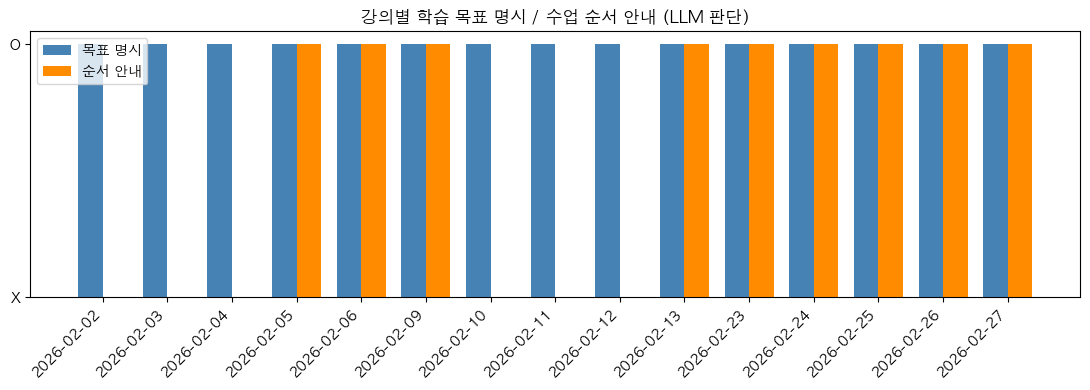

점수 힌트 분포:
score_hint
3    6
5    9

1점(목표 안내 없음): []


In [29]:
# 8-6. 목표/순서 2축 시각화 + 점수 힌트 분포
import numpy as np

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(item4_df)); w = 0.38
ax.bar(x - w/2, item4_df['goal'].astype(int),  w, label='목표 명시', color='steelblue')
ax.bar(x + w/2, item4_df['order'].astype(int), w, label='순서 안내', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(item4_df['date'], rotation=45, ha='right')
ax.set_yticks([0, 1]); ax.set_yticklabels(['X', 'O'])
ax.set_title('강의별 학습 목표 명시 / 수업 순서 안내 (LLM 판단)')
ax.legend()
plt.tight_layout(); plt.show()

print('점수 힌트 분포:')
print(item4_df['score_hint'].value_counts().sort_index().to_string())
print('\n1점(목표 안내 없음):', item4_df[item4_df['score_hint'] == 1]['date'].tolist())


**EDA 결과 — 항목 4 학습 목표 안내**

EDA 결과, 도입부 30분 kss 문장에서 **시작 블록(25문장) + GOAL 키워드 밀집 윈도우**를 후보로 뽑아
LLM(Gemini 2.5 Flash)이 **목표·순서 2축**으로 판단했다.

| 지표 | 결과 |
|------|------|
| 목표 명시(goal_stated) | **15/15 (100%)** |
| 순서 안내(order_mentioned) | **9/15 (60%)** |
| 점수 힌트 분포 | 3점 6개 / 5점 9개 / 1점 0개 |

이를 분석하면, 이 강사는 **거의 모든 강의에서 오늘 배울 내용을 안내**한다(목표 100%). 따라서 변별력은
"목표만 말했나(3점)" vs "수업 진행 순서까지 안내했나(5점)"에서 나온다. 키워드 단독(v1)으로는
`02-03`·`02-25`를 0건(1점)으로 잘못 떨궜는데, **연속 문맥 블록을 LLM에 주니** 실제로는 목표·순서가
있던 강의로 드러났다(예: `02-25`는 "인덱스 개념·필요성 + 순서" 안내 → 5점). 즉 v1의 "1점"은
목표 부재가 아니라 **추출 누락**이었다.

**채점 매핑**
- **1점**: goal_stated=False (이 데이터셋엔 없음)
- **3점**: 목표만 — 02-02·03·04·10·11·12
- **5점**: 목표 + 순서 — 02-05·06·09·13·23·24·25·26·27
- **4점**: 순서가 불완전한 경우 LLM 보조 판단 여지

**확인하지 못한 것**: 목표·순서의 '품질'(구체성·정확성)에 따른 4↔5 세부 차등은 추가 LLM 기준이 필요.
또한 `02-03`("~설명할 수 있다라고 했었는데")처럼 복습 회고형은 목표 판정이 경계선이라, 제외 기준
강화 여지가 있다. (캐시: `llm_cache_item4_v2.json`)

---
## 9. 항목 5 — 전날 복습 연계

**EDA 목표**
1. 복습 키워드 탐지율 확인
2. 복습 관련 연속 발화 블록 어절 수 분포

### 9-1. 항목 4와 동일 골격 — 탐지율과 근거를 함께 출력

**왜 같은 구조인가** — 복습 연계도 "도입부 30분·kss 문장"이라는 동일 전제를 공유한다
(코드 재사용·일관성). 탐지율과 강의별 문장을 *함께* 출력하는 이유는, 다음 셀에서 밝히듯
"탐지율 100%"를 성과로 오해하지 않기 위해 근거 문장을 같이 봐야 하기 때문이다.

In [30]:
# 9-1. 도입부 kss 문장 기준 복습 키워드 탐지 + 강의별 출력
REVIEW_KEYWORDS = [
    '지난', '복습', '어제', '저번', '이전', '지난 시간', '기억',
    '저번 시간', '지난번', '배웠', '했던', '다뤘', '앞에서',
]

def has_review_keyword(text: str) -> bool:
    return any(kw in str(text) for kw in REVIEW_KEYWORDS)

records = []
review_sents_by_lecture = {}

for lid, g in df.groupby('lecture_id'):
    g = g.reset_index(drop=True)
    intro_text  = ' '.join(g[g['elapsed_sec'] <= INTRO_SEC]['text_clean'].tolist())
    intro_sents = kss.split_sentences(intro_text, backend='fast')
    hits = [s for s in intro_sents if has_review_keyword(s)]
    review_sents_by_lecture[lid] = hits
    records.append({
        'date':        lid[:10],
        'total_sents': len(intro_sents),
        'hit_count':   len(hits),
        'detected':    len(hits) > 0,
    })

review_df = pd.DataFrame(records)
print(f'탐지율: {review_df["detected"].mean():.0%}  ({review_df["detected"].sum()}/{len(review_df)} 강의)')
display(review_df[['date','total_sents','hit_count','detected']])

print(f'\n{"="*65}')
print('▶ 강의별 복습 연계 탐지 문장 (검증용)')
print(f'{"="*65}')
for lid, sents in review_sents_by_lecture.items():
    print(f'\n[{lid[:10]}]  {len(sents)}건')
    for s in sents:
        kw = [k for k in REVIEW_KEYWORDS if k in s]
        print(f'  · ({", ".join(kw)}) {s}')


탐지율: 100%  (15/15 강의)


,date,total_sents,hit_count,detected
0,2026-02-02,162,13,True
1,2026-02-03,96,12,True
2,2026-02-04,195,25,True
3,2026-02-05,177,13,True
4,2026-02-06,167,16,True
5,2026-02-09,136,3,True
6,2026-02-10,138,8,True
7,2026-02-11,156,21,True
8,2026-02-12,168,23,True
9,2026-02-13,129,20,True



▶ 강의별 복습 연계 탐지 문장 (검증용)

[2026-02-02]  13건
  · (지난, 지난 시간) 그래서 지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 이해를 하고 그다음에 데이터 흐름 읽기 쓰기를 구현하는 날이에요.
  · (이전) 일본이 이제 옛날부터 1.0부터 나왔던 거고, 2하고 3은 7버전 이전부터는 쓰고 있는데, 21 버전에는 보통 뭘 쓰냐면 여기 있는 네트워크 구현할 때는 정해져 있어요.
  · (어제) 한번 살짝 눌러보면 약간 기다리고는 있지만 그래도 눌러볼게요 여기 보면 얘가 지금 1번이 코어 라이브러리 그 다음에 이제 사부작사부작 내려서 컬렉션 프레임워크이라는 걸 눌러 우리가 이제 예전 어제 금요일 날이죠.
  · (지난) 지난주 아 목요일입니까?
  · (했던) 기본적으로 했던 그 컬렉션 프레임워 카테고리가 여기 들어와 있어 여기 들어와 있고 그 다음에 베이스는 없고 자바를 지금 라이브러리 단위로 접근해서 공부하고 싶다
  · (했던) 그 중에서 이제 5번이 저희가 했던 거라서 자바 컬렉션 프레임웍크를 살짝 누르면 여기 지금 현재 독스로 넘어가서 현재 컬렉션의 프레임워크라든지큐멘테이션이라든지.
  · (했던) 여기에 튜토리얼로 다시 연결이 얘는 누르면 다시 우리 메인 튜토리얼로 넘어가서 지금 현재 사이트랑 동일 궁금하면 눌렀다 오시고 살짝 좀 지우 전체 이제 오버뷰가 되어 있어서 저희가 했던 내용들을 살짝 보여주고 있습니다.
  · (했던) 이렇게 그래서 버전부터 시작해 저희가 사용했던 소스코드가 20일 수업시간에 했던 내용들 이렇게 20일 코드예요.
  · (지난, 지난번) 그렇지 우리 지난번에 리스트 오으로 하셨죠.
  · (했던) 저희가 수업 시간에 했던 여기 리버시드라고 하는 것도 볼 수가 있습니습니다.
  · (기억) 임시기억장소 중에 하나지 그 임시기억장소가 전체적으로 네 가지가 있다고 말했어.
  · (기억) 하나의 임시기억 장소 형태를 클래스로 만들어 가지고 데이터를 입력한 다음에 

### 9-2. "건수 ≠ 품질" 을 데이터로 보인다

**왜 건수와 어절 수를 보나** — 복습 문장이 많다고 복습을 잘한 게 아니다. 중요한 건
*구체성*(어제 내용을 오늘과 어떻게 잇는지)이고, 이는 길이·내용이라 규칙으로 정량화 불가.
→ 탐지 여부(0건=1점)만 EDA로 거르고, 2~5점은 LLM에 맡긴다는 결론의 근거.

복습 문장 합계: 209건  |  강의당 평균 13.9건


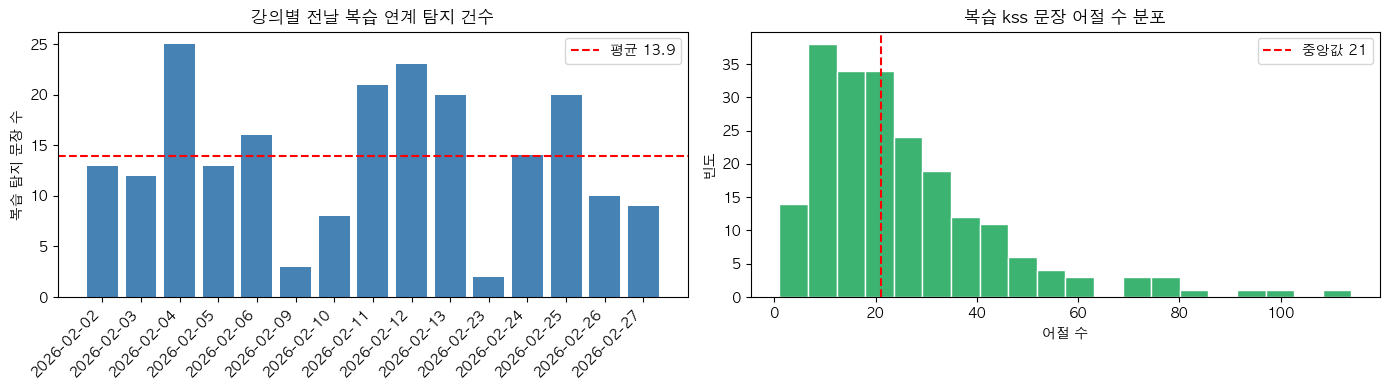

In [31]:
# 9-2. 강의별 복습 탐지 건수 + 복습 문장 어절 수 분포
review_sent_records = [
    {'lecture_id': lid, 'sentence': s, 'word_count': len(s.split())}
    for lid, sents in review_sents_by_lecture.items()
    for s in sents
]
rs_df = pd.DataFrame(review_sent_records)
print(f'복습 문장 합계: {len(rs_df)}건  |  강의당 평균 {len(rs_df)/df["lecture_id"].nunique():.1f}건')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (좌) 강의별 복습 탐지 건수
axes[0].bar(range(len(review_df)), review_df['hit_count'], color='steelblue')
axes[0].axhline(review_df['hit_count'].mean(), color='red', linestyle='--',
                label=f'평균 {review_df["hit_count"].mean():.1f}')
axes[0].set_xticks(range(len(review_df)))
axes[0].set_xticklabels(review_df['date'], rotation=45, ha='right')
axes[0].set_ylabel('복습 탐지 문장 수')
axes[0].set_title('강의별 전날 복습 연계 탐지 건수')
axes[0].legend()

# (우) 복습 문장 어절 수 분포
axes[1].hist(rs_df['word_count'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1].axvline(rs_df['word_count'].median(), color='red', linestyle='--',
                label=f'중앙값 {rs_df["word_count"].median():.0f}')
axes[1].set_xlabel('어절 수')
axes[1].set_ylabel('빈도')
axes[1].set_title('복습 kss 문장 어절 수 분포')
axes[1].legend()

plt.tight_layout()
plt.show()


**EDA 결과 — 항목 5 전날 복습 연계**

EDA 결과, 도입부 30분 kss 문장에서 복습 키워드(지난/어제/배웠/했던 등)를 탐지하니 탐지율 100%(15/15강의), 강의당 평균 13.9건(최소 2건, 최대 25건)이 나왔다.

이를 분석하면, 탐지율 100%는 좋은 신호가 아니라 키워드가 너무 광범위해 거의 모든 강의에서 잡힌 결과다. 실제로 hit_count가 높다고 복습 연계가 잘 된 것은 아니며, 중요한 것은 복습 언급의 **구체성·연결성**(어제 한 내용을 오늘과 어떻게 잇는지)이다.

**확인하지 못한 것**: 복습의 '질'은 정답 라벨이 없어 EDA 단계에서 정량화할 수 없었다 → 항목 4와 동일하게 LLM 채점으로 이관한다.

따라서 탐지 여부(0건이면 1점)는 EDA로 거르되, 2~5점은 LLM이 복습 문장의 구체성을 기준으로 채점하는 방향이 좋겠다.

---
## 10. 항목 9 — 개념 정의

**EDA 목표**
1. 정의 패턴 문장 탐지 수 확인 (강의별)
2. 정의 문장 샘플 확인 → 패턴 적합성 검토

### 10-1. rate가 불가능하므로 "절대 수"로 — 그리고 패턴 한계 노출

**왜 비율이 아니라 수인가** — definition_rate는 분모(그 강의에서 정의*했어야 할* 개념
총수)를 알 수 없어 산출 불가능하다. 그래서 정의 문장 **절대 수**로 측정한다. 매칭 문장을
함께 출력해 `이라고`·`이란`이 단순 명명("NIO라고 하는 게")까지 잡는 한계를 드러낸다.

In [32]:
# 10-1. 정의 패턴 탐지 — 강의별 정의 문장 수 + 출력
import re as _re

DEFINITION_PATTERNS = [
    r'이란', r'라고\s*(합니다|해요|하죠|불러)', r'이라고',
    r'의\s*정의', r'뜻은', r'의미는', r'개념은',
    r'이라는\s*(것|게|건)', r'라는\s*(것|게|건)',
]

def is_definition(text: str) -> bool:
    return any(_re.search(p, str(text)) for p in DEFINITION_PATTERNS)

df['is_definition'] = df['text_clean'].apply(is_definition)

def_stats = (
    df.groupby('date')['is_definition']
    .agg(def_count='sum', utterance_count='count')
)
print('강의별 정의 문장 수:')
display(def_stats)
print(f'\n강의당 평균: {def_stats["def_count"].mean():.1f}건')

print(f'\n{"="*65}')
print('▶ 강의별 탐지 정의 문장 (검증용, 강의당 최대 10건)')
print(f'{"="*65}')
for date, grp in df[df['is_definition']].groupby('date'):
    print(f'\n[{date}]  {len(grp)}건')
    for _, row in grp.head(10).iterrows():
        pat = [p for p in DEFINITION_PATTERNS if _re.search(p, str(row["text_clean"]))]
        print(f'  · ({pat[0] if pat else "?"}) {str(row["text_clean"])[:120]}')


강의별 정의 문장 수:


,def_count,utterance_count
date,,
2026-02-02,46,1484
2026-02-03,54,1860
2026-02-04,65,1771
2026-02-05,64,1656
2026-02-06,32,1671
2026-02-09,35,1555
2026-02-10,50,1672
2026-02-11,57,1560
2026-02-12,29,986



강의당 평균: 49.7건

▶ 강의별 탐지 정의 문장 (검증용, 강의당 최대 10건)

[2026-02-02]  46건
  · (이라고) 스트림 단위로 구현을 해주는 자바 NIO 여기 보면 파일이라고 하는 객체를 가지고 있는 패키지가 이렇게 세 가지가 있어요.
  · (이라고) 포크스레드 포크 조인 스트림이라고 하는 게 있는데, 거기에 이제 네트워크를 조금 빠르게 구현하기 위해서 그다음에 세 번째 섹션이DK 7버전 이후부터
  · (이라고) 버퍼가 있고 이 버퍼에 담아서 여기 채널이라고 하는 걸 통해서 셀렉터를 하거든요. 그래서 실제 NIO 밑에
  · (이라고) 마 이렇게 섹션이 나눠져 있습니다장 그다음에 자바 NIO에 가서 이거 파이즈라고 하는 패키지를 살짝 누르면 얘네들은 간단하게 파이라고 일단
  · (이라는\s*(것|게|건)) 그 다음에 오늘은 JDK21의 코아에 NIO HTML이라는 것을 링크해드렸는데 이거는 지금 보시면 뭐 별거 없어요.
  · (이라고) 셋과 솔티드 셋 그다음에 네비게블 셋이라고 해서 프리비어스 갔다 하는 애들의 객체가 이렇게 있고 그다음 저희는 이제 리스트 밑에 어레이 리스트
  · (이라는\s*(것|게|건)) 의외로 J셀이라는 것을 또 많이 사용할 수도 있는데, 자바셀 별거 아닙니다.
  · (이라고) 싱글 A도 이렇게 한번 넣어보고 그러면은 달러 1번 달러 2원 달러 3번이라고 해서 우리 프린트 F 했을 때% 서식 만들어주듯이 얘가 위치 만들어서 구현해 주는 거 이렇게 해서
  · (이라고) 바이트 단위로 데이터가 흐르는 그때 선을 이렇게 그려주면서 그 통로가 스트림이다. 그서 스트림이라고
  · (이라고) 그래도 전부 다 내부적으로 겟바이트스라는 메소드를 이용해서 바이트 단위로 일단 처리가 돼 스트림이라고 자체는 여기 내가 하나 넣어놨어 데이터가 한 방향으로 흐르는 통로를

[2026-02-03]  54건
  · (이라고) 인풋이라고 자체는 외부 데이터를 프로그램으로 읽어오는 것을 얘기하는 거고, 아웃풋의 출력이라고 하는

### 10-2. 절대 수 분포 시각화 — "상대 비교용"임을 분명히

**왜 분포만 보나** — rate가 아니므로 절대값 자체엔 의미를 둘 수 없고, 강의 간
*상대 비교* 지표로만 쓴다. 진짜 정의 여부 판정은 LLM 검증으로 넘긴다.

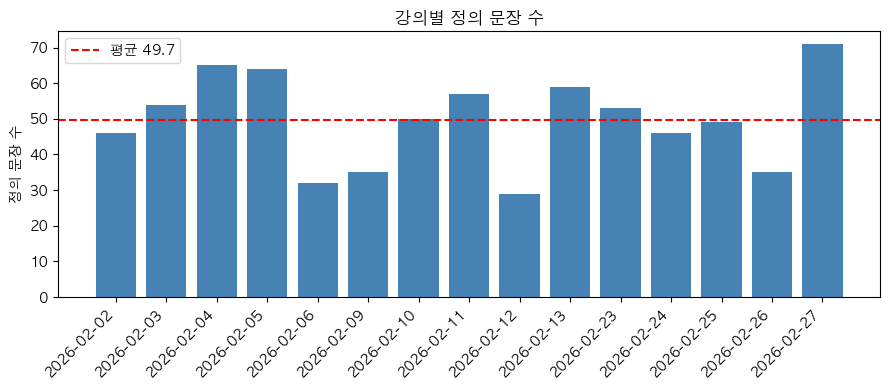

In [33]:
# 10-2. 정의 문장 수 분포 시각화
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(def_stats)), def_stats['def_count'], color='steelblue')
ax.axhline(def_stats['def_count'].mean(), color='red', linestyle='--',
           label=f'평균 {def_stats["def_count"].mean():.1f}')
ax.set_xticks(range(len(def_stats)))
ax.set_xticklabels(def_stats.index.tolist(), rotation=45, ha='right')
ax.set_ylabel('정의 문장 수')
ax.set_title('강의별 정의 문장 수')
ax.legend()
plt.tight_layout()
plt.show()


**EDA 결과 — 항목 9 개념 정의**

EDA 결과, 정의 패턴(이란/이라고/의 정의/뜻은 등)으로 탐지한 정의 문장은 강의당 평균 49.7건(최소 29건 02-12, 최대 71건 02-27), 전체 합계 745건이었다.

이를 분석하면, `이라고`·`이란` 패턴이 실제 개념 정의뿐 아니라 "NIO라고 하는 게" 같은 단순 명명까지 잡아 수치가 다소 부풀려졌을 가능성이 있다.

**확인하지 못한 것**: "그 강의에서 정의했어야 할 전체 개념 수"를 알 수 없어 definition_rate(정의율)는 산출할 수 없었다 → 비율 대신 **절대 수**로 대체했다. 단순 명명과 진짜 정의의 구분도 패턴만으로는 한계라 LLM 검증이 필요하다.

따라서 정의 문장 절대 수를 강의 간 비교 지표로 쓰되, 실제 정의 여부 판정은 LLM에 맡기는 기준이 좋겠다.

---
## 11. 항목 10 — 비유 및 예시 활용

**EDA 목표**
- 예시/비유 키워드 탐지율 및 분포 확인
- 핵심 기술 용어 최초 등장 후 5문장 이내 예시 키워드 등장 여부

### 11-1. 예시/비유 후보 수집 — 오탐 비중을 미리 가늠

**왜 출력까지 하나** — `처럼`·`마치` 같은 키워드는 "우리처럼" 같은 단순 인칭 비교까지
잡는다. 강의별 문장을 출력해 *오탐 비중*을 눈으로 확인하는 이유는, 이 후보가 그대로
항목 13 LLM 판단의 입력이 되기 때문이다(입력 품질 점검).

강의별 예시/비유 발화 수:


,ex_count,utterance_count
date,,
2026-02-02,7,1484
2026-02-03,7,1860
2026-02-04,14,1771
2026-02-05,24,1656
2026-02-06,13,1671
2026-02-09,12,1555
2026-02-10,21,1672
2026-02-11,21,1560
2026-02-12,8,986



강의당 평균: 14.0건


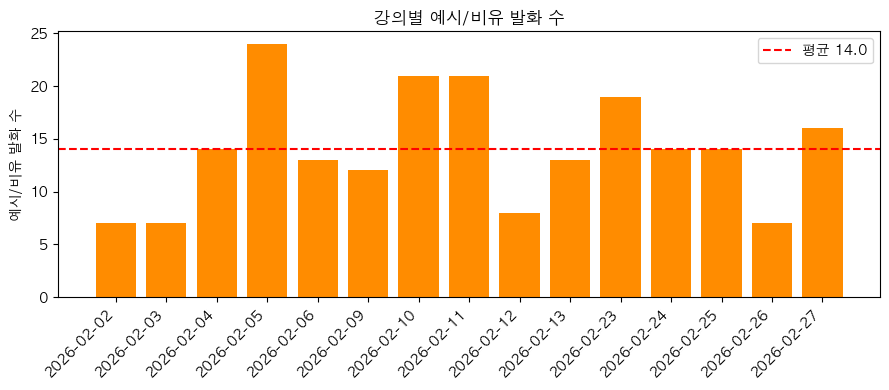


▶ 강의별 탐지 예시/비유 문장 (검증용, 강의당 최대 10건)

[2026-02-02]  7건
  · (쉽게 말해서) 담았다가 일괄로 다 채워지면 보내주는 그래서 우리가 쉽게 말해서 버퍼링을 생각하면 된다고 얘기했어요.
  · (예를 들어) 예를 들어서 내가 파일을 새로 생성하고 새로 생성하고 그 다음에존의 파일이 있으면 덮어쓰기 하고 싶으면 스탠다드 옵션 오픈에 크리에이트도 쓰고 콤마 보면 트렁크에이트가 가지고 있는
  · (예를 들어) 각각의 객체에다가 아이디를 붙여서 식별을할 수 있는 우리가 생각하는 클래스는 예를 들어서 퍼이에 퍼슨 하나야요 그게 아니고 퍼슨도 보내고 스튜던트도 보내고 스코어
  · (예를 들어) 내가 예를 들어서 스코어트 코어 이런 식으로 파일에다 썼어 그러면 읽을 때도 똑같이 순서를 지켜야 돼 코어 인트 스코어 그러다 보니까 리드 바이트 리드 캐릭터
  · (생각해보면) 객체 저장이지 그럼 전부 다 오브젝트 인풋 스트림 아웃풋 스트림 하셔야 돼 지금 가만히 생각해보면 단위로 쓰는 것보다 화이트냐 아니면 객체냐를 훨씬
  · (예를 들어) 탐색이라기보다도 탐색을 해서 딜리트 할 때 많이 쓰는 거지 예를 들어서 여기 애들을 다 지우고 싶어 그러 하위 애들 다 지우고 그다음에 자기 자신이 지우는 그래서 보통 삭제할 때 많이 쓴다 호스트 밑에
  · (예를 들어) 예를 들어 그서 인터페이스를 상속을 받아서 탐색하는 방법 인터페이스를 임플리먼트한 클래스를 익스텐즈를 해서 원하는 메소드를 사용해서 트리에

[2026-02-03]  7건
  · (생각해보면) 문자 스트림을 어제 가만히 생각해보면 코드가 바이트 단위는 캐릭터 셋을 지정하는 것을 둔감합니다.
  · (예를 들어) 저희가 예를 들어서 똑같은 아웃풋 스트림 인풋 스트림의 객체를 메소드나 클러스로 사용을 한다고 해도 내가 만약에 문자열 단위로 읽고 쓴다 그러면 문자 인코딩이나
  · (생각해보면) 얘가 가지고 있는 오버라이드 메소드를 생각해보면 디렉토리를 탐색할 수 있고 그 다음에 파

In [34]:
# 11-1. 예시/비유 키워드 탐지 — 강의별 수 + 출력
EXAMPLE_KEYWORDS = [
    '예를 들어', '예를 들면', '예시', '비유', '마치', #'처럼',
    '같이 생각', '쉽게 말하면', '쉽게 말해서', '쉽게 말해',
    '예를들어', '예컨대', '비슷하게', '생각해보면',
]

def has_example_keyword(text: str) -> bool:
    return any(kw in str(text) for kw in EXAMPLE_KEYWORDS)

df['is_example'] = df['text_clean'].apply(has_example_keyword)

ex_stats = (
    df.groupby('date')['is_example']
    .agg(ex_count='sum', utterance_count='count')
)
print('강의별 예시/비유 발화 수:')
display(ex_stats)
print(f'\n강의당 평균: {ex_stats["ex_count"].mean():.1f}건')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(ex_stats)), ex_stats['ex_count'], color='darkorange')
ax.axhline(ex_stats['ex_count'].mean(), color='red', linestyle='--',
           label=f'평균 {ex_stats["ex_count"].mean():.1f}')
ax.set_xticks(range(len(ex_stats)))
ax.set_xticklabels(ex_stats.index.tolist(), rotation=45, ha='right')
ax.set_ylabel('예시/비유 발화 수')
ax.set_title('강의별 예시/비유 발화 수')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n{"="*65}')
print('▶ 강의별 탐지 예시/비유 문장 (검증용, 강의당 최대 10건)')
print(f'{"="*65}')
for date, grp in df[df['is_example']].groupby('date'):
    print(f'\n[{date}]  {len(grp)}건')
    for _, row in grp.head(10).iterrows():
        kw = [k for k in EXAMPLE_KEYWORDS if k in str(row['text_clean'])]
        print(f'  · ({kw[0] if kw else "?"}) {str(row["text_clean"])[:120]}')


### 11-2. 단순 빈도를 넘어 "구조적 적절성" 시도

**왜 커버리지를 보나** — 좋은 강의는 새 기술 용어를 꺼낸 *직후* 예시를 든다는 가설을
검증한다. 기술 용어(영문 토큰) 최초 등장 후 **5문장 이내** 예시 키워드가 따라오는 비율을
측정 — 예시의 "양"이 아니라 "타이밍"을 보는 보조 지표다.

In [35]:
# 11-2. 기술 용어 최초 등장 → 5문장 이내 예시 등장 여부
import re as _re2
TECH_TERM_PATTERN = _re2.compile(r'[A-Za-z]{3,}')

results = []
for _, block in blocks_df.iterrows():
    sents = block.get('sentences', [])
    if not sents:
        continue
    seen = set()
    for i, sent in enumerate(sents):
        new_terms = set(TECH_TERM_PATTERN.findall(sent)) - seen
        seen |= set(TECH_TERM_PATTERN.findall(sent))
        for term in new_terms:
            window = sents[i:i+6]
            results.append({
                'lecture_id': block['lecture_id'],
                'term': term,
                'has_example_in_5': any(has_example_keyword(s) for s in window),
            })

term_df = pd.DataFrame(results)
coverage = term_df['has_example_in_5'].mean()
print(f'기술 용어 최초 등장 후 5문장 이내 예시 커버리지: {coverage:.1%}')
print(f'총 분석 용어 수: {len(term_df)}')
print(term_df.groupby('lecture_id')['has_example_in_5'].mean().round(3).to_string())


기술 용어 최초 등장 후 5문장 이내 예시 커버리지: 6.2%
총 분석 용어 수: 1037
lecture_id
2026-02-02_kdt-backendj-21th    0.051
2026-02-03_kdt-backendj-21th    0.026
2026-02-04_kdt-backendj-21th    0.056
2026-02-05_kdt-backendj-21th    0.091
2026-02-06_kdt-backendj-21th    0.050
2026-02-09_kdt-backendj-21th    0.011
2026-02-10_kdt-backendj-21th    0.069
2026-02-11_kdt-backendj-21th    0.065
2026-02-12_kdt-backendj-21th    0.071
2026-02-13_kdt-backendj-21th    0.068
2026-02-23_kdt-backendj-21th    0.115
2026-02-24_kdt-backendj-21th    0.108
2026-02-25_kdt-backendj-21th    0.043
2026-02-26_kdt-backendj-21th    0.158
2026-02-27_kdt-backendj-21th    0.040


**EDA 결과 — 항목 10 비유 및 예시 활용**

EDA 결과, 예시/비유 키워드(예를 들어/마치/처럼/생각해보면 등)로 탐지한 발화는 강의당 평균 25.1건(최소 13건 02-26, 최대 41건 02-05)이었다.

이를 분석하면, `처럼` 패턴이 가장 큰 비중을 차지했는데 "우리처럼", "저처럼" 같은 단순 인칭 비교까지 잡아 오탐이 섞여 있었다. 반면 `예를 들어`, `마치`, `생각해보면`은 실제 예시·비유 설명에 가까웠다.

**확인하지 못한 것**: 예시가 "적절한지"(수준·관련성)는 키워드만으로 판단 불가라 항목 13에서 LLM이 별도로 검증한다.

따라서 키워드 탐지는 후보 수집용으로만 쓰고, 적절성 판정은 LLM에 맡기는 기준이 좋겠다. (`처럼`은 오탐이 많아 단독 근거로는 신뢰도를 낮게 둔다.)

---
## 12. 항목 13 — 예시 적절성

**EDA 목표**
- `level_ok_ratio`, `relevance_high_ratio` 분포 확인
- 이전 강의 메타데이터 → 수강생 수준 측정 → 예시 적절성 LLM 판단 파이프라인 검증용

> **참고**: 이 항목은 LLM 판단 의존도가 높음.  
> EDA 단계에서는 예시 발화 수 분포와 예시 키워드 패턴 확인으로 한정.

### 12-1. 항목 10 → 13 직접 연결 — LLM이 적절성을 판단

**왜 LLM인가** — "예시가 수강생 수준에 맞는가(level_ok)", "주제와 관련 있는가(relevance)"는
키워드로 절대 알 수 없는, 의미 판단의 영역이다. 항목 10이 모은 예시 후보를 LLM이 두 축으로
채점한다. 규칙이 못 하는 일을 정확히 여기서 메운다.

In [36]:
# 12-1. LLM 기반 예시 적절성 판단 (level_ok / relevance_high)
import os, json as _json, re as _re3, time
from pathlib import Path
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
_client = OpenAI(
    api_key=os.getenv('OPENAI_API_KEY', ''),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)
_MODEL = 'models/gemini-2.5-flash'

_CACHE_PATH = Path('../data/processed/llm_cache_item13.json')
_cache13: dict = _json.loads(_CACHE_PATH.read_text()) if _CACHE_PATH.exists() else {}

_SYS = "당신은 강의 품질 분석 전문가입니다. 백엔드 개발 입문 강의의 예시/비유 발화를 평가합니다."

def _judge_examples(lid: str, utterances: list) -> list:
    """최대 10개 예시 발화 → LLM 판단 [{level_ok, relevance}]."""
    if lid in _cache13:
        return _cache13[lid]
    if not utterances:
        _cache13[lid] = []
        _CACHE_PATH.write_text(_json.dumps(_cache13, ensure_ascii=False, indent=2))
        return []
    sample = utterances[:10]
    numbered = '\n'.join(f'{i+1}. {s}' for i, s in enumerate(sample))
    msg = f"""다음은 백엔드 개발 입문 강의에서 예시/비유로 분류된 발화입니다.

{numbered}

각 발화에 대해 판단하세요:
- level_ok: 입문 수강생 수준에 적합한 예시인가? (true/false)
- relevance: 강의 주제(SQL·Java·DB)와 관련 있는 예시인가? (high/medium/low)

**반드시 JSON 배열만** 출력:
[{{"idx":1,"level_ok":true,"relevance":"high"}}, ...]"""
    resp = _client.chat.completions.create(
        model=_MODEL,
        messages=[{"role":"system","content":_SYS}, {"role":"user","content":msg}],
        temperature=0.1,
    )
    raw = resp.choices[0].message.content.strip()
    m   = _re3.search(r'\[[\s\S]*\]', raw)
    result = _json.loads(m.group()) if m else []
    _cache13[lid] = result
    _CACHE_PATH.write_text(_json.dumps(_cache13, ensure_ascii=False, indent=2))
    time.sleep(32)
    return result

print(f'모델: {_MODEL}\n{"="*65}')
item13_records = []
for lid, grp in df[df['is_example']].groupby('lecture_id'):
    cached = lid in _cache13
    utts   = grp['text_clean'].tolist()
    judgments = _judge_examples(lid, utts)
    for j in judgments:
        item13_records.append({
            'lecture_id':    lid,
            'date':          lid[:10],
            'level_ok':      j.get('level_ok', None),
            'relevance':     j.get('relevance', None),
        })
    tag = '(캐시)' if cached else '(API)'
    lo  = sum(1 for j in judgments if j.get('level_ok')) if judgments else 0
    rh  = sum(1 for j in judgments if j.get('relevance') == 'high') if judgments else 0
    n   = len(judgments)
    print(f'[{lid[:10]}] {n}건 판단  level_ok={lo}/{n}  relevance_high={rh}/{n}  {tag}')

item13_df = pd.DataFrame(item13_records)


모델: models/gemini-2.5-flash
[2026-02-02] 10건 판단  level_ok=10/10  relevance_high=10/10  (캐시)
[2026-02-03] 10건 판단  level_ok=10/10  relevance_high=10/10  (캐시)
[2026-02-04] 10건 판단  level_ok=9/10  relevance_high=7/10  (캐시)
[2026-02-05] 10건 판단  level_ok=8/10  relevance_high=7/10  (캐시)
[2026-02-06] 10건 판단  level_ok=10/10  relevance_high=8/10  (캐시)
[2026-02-09] 10건 판단  level_ok=10/10  relevance_high=9/10  (캐시)
[2026-02-10] 10건 판단  level_ok=10/10  relevance_high=10/10  (캐시)
[2026-02-11] 10건 판단  level_ok=9/10  relevance_high=9/10  (캐시)
[2026-02-12] 10건 판단  level_ok=10/10  relevance_high=8/10  (캐시)
[2026-02-13] 10건 판단  level_ok=8/10  relevance_high=8/10  (캐시)
[2026-02-23] 10건 판단  level_ok=4/10  relevance_high=9/10  (캐시)
[2026-02-24] 10건 판단  level_ok=9/10  relevance_high=9/10  (캐시)
[2026-02-25] 10건 판단  level_ok=8/10  relevance_high=8/10  (캐시)
[2026-02-26] 10건 판단  level_ok=10/10  relevance_high=10/10  (캐시)
[2026-02-27] 10건 판단  level_ok=10/10  relevance_high=5/10  (캐시)


### 12-2. 이상치 탐지 + 판단 근거 공개

**왜 비율 시각화 + 원문인가** — 강의별 level_ok·relevance 비율로 *낮은 강의*(개선 피드백
대상)를 찾는다. 동시에 LLM 원문 판단을 함께 출력해, 팀이 "왜 이 예시가 부적합으로
판정됐는지"를 직접 검증할 수 있게 한다(블랙박스 방지).

강의별 예시 적절성:


,n,level_ok_ratio,relevance_high_ratio
date,,,
2026-02-02,10,1.0,1.0
2026-02-03,10,1.0,1.0
2026-02-04,10,0.9,0.7
2026-02-05,10,0.8,0.7
2026-02-06,10,1.0,0.8
2026-02-09,10,1.0,0.9
2026-02-10,10,1.0,1.0
2026-02-11,10,0.9,0.9
2026-02-12,10,1.0,0.8



전체 level_ok_ratio:       90.0%
전체 relevance_high_ratio:  84.7%


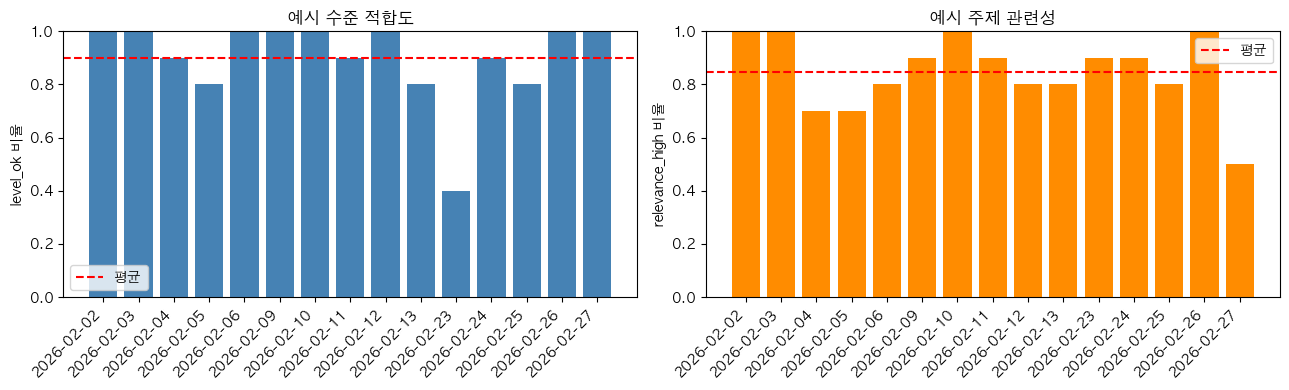


▶ LLM 판단 원문 — 강의별 예시 발화 + 평가 결과

[2026-02-02]
  ✅ [high  ] 담았다가 일괄로 다 채워지면 보내주는 그래서 우리가 쉽게 말해서 버퍼링을 생각하면 된다고 얘기했어요.
  ✅ [high  ] 예를 들어서 내가 파일을 새로 생성하고 새로 생성하고 그 다음에존의 파일이 있으면 덮어쓰기 하고 싶으면 스탠다드 옵션 오픈에 크리에이트도 쓰고 콤마 보면 트렁크에이트가 가지고 있는
  ✅ [high  ] 각각의 객체에다가 아이디를 붙여서 식별을할 수 있는 우리가 생각하는 클래스는 예를 들어서 퍼이에 퍼슨 하나야요 그게 아니고 퍼슨도 보내고 스튜던트도 보내고 스코어
  ✅ [high  ] 내가 예를 들어서 스코어트 코어 이런 식으로 파일에다 썼어 그러면 읽을 때도 똑같이 순서를 지켜야 돼 코어 인트 스코어 그러다 보니까 리드 바이트 리드 캐릭터
  ✅ [high  ] 객체 저장이지 그럼 전부 다 오브젝트 인풋 스트림 아웃풋 스트림 하셔야 돼 지금 가만히 생각해보면 단위로 쓰는 것보다 화이트냐 아니면 객체냐를 훨씬
  ✅ [high  ] 탐색이라기보다도 탐색을 해서 딜리트 할 때 많이 쓰는 거지 예를 들어서 여기 애들을 다 지우고 싶어 그러 하위 애들 다 지우고 그다음에 자기 자신이 지우는 그래서 보통 삭제할 때 
  ✅ [high  ] 예를 들어 그서 인터페이스를 상속을 받아서 탐색하는 방법 인터페이스를 임플리먼트한 클래스를 익스텐즈를 해서 원하는 메소드를 사용해서 트리에
  ✅ [high  ] ?
  ✅ [high  ] ?
  ✅ [high  ] ?

[2026-02-03]
  ✅ [high  ] 문자 스트림을 어제 가만히 생각해보면 코드가 바이트 단위는 캐릭터 셋을 지정하는 것을 둔감합니다.
  ✅ [high  ] 저희가 예를 들어서 똑같은 아웃풋 스트림 인풋 스트림의 객체를 메소드나 클러스로 사용을 한다고 해도 내가 만약에 문자열 단위로 읽고 쓴다 그러면 문자 인코딩이나
  ✅ [high  ] 얘가 가지고 있는 오버라이드 메소드

In [37]:
# 12-2. 예시 적절성 분포 시각화
if item13_df.empty:
    print("판단 결과 없음")
else:
    by_date = item13_df.groupby('date').agg(
        n              = ('level_ok', 'count'),
        level_ok_ratio = ('level_ok', 'mean'),
        relevance_high_ratio = ('relevance', lambda x: (x == 'high').mean()),
    ).round(3)
    print('강의별 예시 적절성:')
    display(by_date)
    print(f'\n전체 level_ok_ratio:       {item13_df["level_ok"].mean():.1%}')
    print(f'전체 relevance_high_ratio:  {(item13_df["relevance"] == "high").mean():.1%}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    dates = by_date.index.tolist()
    x = range(len(dates))

    axes[0].bar(x, by_date['level_ok_ratio'], color='steelblue')
    axes[0].axhline(item13_df['level_ok'].mean(), color='red', linestyle='--', label='평균')
    axes[0].set_xticks(x); axes[0].set_xticklabels(dates, rotation=45, ha='right')
    axes[0].set_ylim(0, 1); axes[0].set_ylabel('level_ok 비율'); axes[0].set_title('예시 수준 적합도')
    axes[0].legend()

    axes[1].bar(x, by_date['relevance_high_ratio'], color='darkorange')
    axes[1].axhline((item13_df['relevance'] == 'high').mean(), color='red', linestyle='--', label='평균')
    axes[1].set_xticks(x); axes[1].set_xticklabels(dates, rotation=45, ha='right')
    axes[1].set_ylim(0, 1); axes[1].set_ylabel('relevance_high 비율'); axes[1].set_title('예시 주제 관련성')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'\n{"="*65}')
    print('▶ LLM 판단 원문 — 강의별 예시 발화 + 평가 결과')
    print(f'{"="*65}')
    _utts_by_lid = {lid: grp['text_clean'].tolist()[:10]
                    for lid, grp in df[df['is_example']].groupby('lecture_id')}
    for lid, judgments in _cache13.items():
        utts = _utts_by_lid.get(lid, [])
        print(f'\n[{lid[:10]}]')
        for j in judgments:
            idx  = j.get('idx', 1) - 1
            text = utts[idx] if idx < len(utts) else '?' 
            lo   = '✅' if j.get('level_ok') else '❌'
            rel  = j.get('relevance', '?')
            print(f'  {lo} [{rel:6s}] {str(text)[:100]}')


**EDA 결과 — 항목 13 예시 적절성**

EDA 결과, 항목 10에서 탐지한 예시 발화를 LLM(Gemini 2.5 Flash)이 강의당 최대 10건씩 판단한 결과, 전체 level_ok(수준 적합) 90.0%, relevance_high(주제 관련 높음) 84.7%로 나왔다.

| 날짜 | level_ok | relevance_high | 비고 |
|------|---------|----------------|------|
| 02-23 | **4/10** | 9/10 | ⚠️ 입문 수준 초과 예시 다수 |
| 02-27 | 10/10 | **5/10** | ⚠️ 주제 이탈 예시 다수 |
| 그 외 | 8~10/10 | 7~10/10 | 양호 |

이를 분석하면, 대부분 강의는 예시가 수준·주제에 적합했으나 02-23(수준 부적합 60%)과 02-27(주제 관련성 50%) 두 강의가 뚜렷한 이상치였다.

**확인하지 못한 것 / 한계**: 입력 예시에 항목 10의 `처럼` 오탐이 섞인 채 판단되어 relevance_high가 실제보다 낮게 나왔을 수 있다 → 키워드 정제 후 재측정이 필요하다.

따라서 level_ok·relevance_high 비율을 항목 13 점수의 1차 신호로 쓰되, 키워드 오탐을 줄인 뒤 재검증하는 기준이 좋겠다. (캐시: `llm_cache_item13.json`)

---
# 항목 4·5·9·10·13 종합 — 규칙과 LLM의 분업 경계

EDA로 다섯 항목을 관통해 확인한 것은 **"어디까지 규칙으로 거르고, 어디부터 LLM에
맡길지"의 경계선**이다. 각 항목이 그 경계를 어디에 그었는지 정리한다.

| 항목 | 규칙(EDA)이 거른 것 | LLM에 맡긴 것 | 그렇게 나눈 근거 |
|------|--------------------|---------------|------------------|
| 4 목표 안내 | 0건 = 1점 / regex 후보 추출 | 후보의 목표 진위·구체성(2~5점) | 정형 문구 미사용 → 키워드 정밀화 실패(8-3) |
| 5 복습 연계 | 0건 = 1점 / 복습 문장 탐지 | 복습의 구체성·연결성 | 탐지율 100%지만 건수 ≠ 품질(9-2) |
| 9 개념 정의 | 정의 문장 절대 수 | 단순 명명 vs 진짜 정의 구분 | 분모 부재로 rate 불가 / 패턴 오탐(10-1) |
| 10 비유·예시 | 예시 후보 + 타이밍 커버리지 | — (후보를 13으로 전달) | `처럼` 오탐 다수(11-1) |
| 13 예시 적절성 | (항목 10 후보 재사용) | 수준·관련성 판단 | 적절성은 의미 판단 영역(12-1) |

**일관된 원칙**
1. **단위는 kss 문장, 윈도우는 도입부 30분** — 모든 항목이 동일 전제 위에서 비교 가능.
2. **규칙은 recall, LLM은 precision** — 규칙이 싸게 넓게 모으고, 비싼 LLM은 좁혀진 후보에만.
3. **모든 LLM 판단은 근거(인용·원문)를 함께 남긴다** — 채점이 블랙박스가 되지 않도록.

> **나의 판단**: 이 다섯 항목에서 키워드/regex를 더 정교화하는 것은 한계 수익이 빠르게
> 떨어진다(8-3에서 입증). 규칙은 "후보를 빠짐없이 모으는" 역할에 한정하고, 변별의 책임은
> LLM에 두는 것이 비용·정확도·재현성 면에서 가장 합리적이라고 본다.

---
## 13. 핵심 내용 강조 — 키워드 추출 (블록 TF-IDF → TextTiling)

**평가 항목**: "중요한 내용을 반복·강조하여 전달하는가". 채점하려면 먼저 **각 구간의 핵심
내용(키워드)** 이 무엇인지 정해야 한다 — 그 키워드가 이후 "반복·강조" 판정의 기준이 된다.
Liu et al. 2009(N09-1070) §4.1의 **TF-IDF + POS filtering** 키워드 추출을 따른다.

**전제 검증 — 쉬는 시간은 토픽을 분할하지 못한다**: 쉬는시간 경계 너머 인접 블록 유사도(0.537)가
블록 내부(0.528)와 거의 같았다(분할 신호 ≈ 0). 토픽이 연속으로 흐르기 때문. 그래서 두 단계로 간다.
1. **블록(쉬는시간) 단위 TF-IDF** — 분할이 거칠어도 IDF가 과목 공통어를 깎아 블록별 키워드는 나온다.
2. **TextTiling 토픽 경계 분할** — 어휘 응집도가 꺼지는 골을 찾아 진짜 토픽 세그먼트로 재추출.

> POS는 명사(NNG/NNP)만 쓴다 — STT에서 동사·형용사는 `하다/되다` 등 노이즈가 많다.
> 논문의 word clustering(SRILM)·sentence salience는 외부 의존/추가 정교화라 v1에서는 보류.

### 13-1. 블록(쉬는시간) 단위 TF-IDF + 토큰 전처리 파이프라인

**왜 먼저 블록인가** — `blocks_df`(쉬는시간 블록)를 문서로 TF-IDF. 명사만 남기고(POS filtering), 한 블록 3회·2블록 이상 등장 명사만 후보로 둬 일회성 파편을 억제한다.

**토큰 파이프라인**: 원문 → **Kiwi 형태소 분석** → 명사(NN*)+**영문(SL) 토큰 보존** → **음차 정규화 사전** → **표기 변형 통합** → 키워드.

**형태소 분석기 — Mecab vs Kiwi 비교 후 Kiwi 채택**:

| 어절 | Mecab | Kiwi |
|------|-------|------|
| 인스턴스가 | 인/스턴스/가 ❌ | 인스턴스/가 ✅ |
| 컨스트레인트를 | 컨스/트레인/트/를 ❌ | 컨스트레인트/를 ✅ |
| 리더의 | 리더/의(NNG 오태깅) | 리더 + 의(JKG) ✅ |
| 셀렉트라고 | 셀렉/트라고 ❌ | 셀렉트 + 이/라고 ✅ |

Mecab은 OOV 외래어를 쪼개 어절-stem·`의` 처리·동사strip 같은 hack이 필요했지만, Kiwi는 분석 단계에서 근본 해결(전체 코퍼스 15초, 1회성). → **Kiwi 채택, hack 제거**.

- **영문(SL) 복구**: Kiwi가 `DB/API/PK/SQL`을 SL로 분리 → 버리지 않고 키워드로 살림(`DDL/DML/DCL/TCL`·`EMP`·`MySQL` 등 32개 복구). 이전엔 영문 시작 토큰을 통째로 버려 누락됐었다.
- **음차 정규화 사전(seed)**: 분석기로 못 푸는 표기 변형을 토큰 단위 매핑(`아이오/입출력→IO`, `마이에스큐*→MySQL`, `NI2/NIO2→NIO`). 자동 탐지 불가(NNG/NNP로 음차 구분 안 됨)라 빈도순 후보를 사람이 확정·확장.
- **표기 변형 통합(word clustering)**: Kiwi 후에도 남는 파편(`셀렉` 87 vs `셀렉트` 571)을 접두 일치 완성형으로 흡수. 사전 등재어는 보호해 `기본키→기본`·`마이너스→마이` 오병합을 막는다.

In [ ]:
# 13-1. 블록 단위 TF-IDF — Kiwi 형태소 분석 + 영문 복구(SL) + 음차 정규화 + 변형 통합
import math
from collections import Counter, defaultdict
from kiwipiepy import Kiwi   # pip install kiwipiepy

_kiwi = Kiwi()
# 사용자 사전: Kiwi가 분해/오인하는 복합·음차 도메인어를 단일 토큰으로
for _w in ['세이브포인트', '아이오', '참조무결성', '외래키', '기본키', '데이터베이스', '서브쿼리']:
    _kiwi.add_user_word(_w, 'NNP')

# 과목 공통어·잡음 불용어
KW_STOP = {'오늘','이거','이제','저희','우리','지금','부분','내용','경우','정도','얘기','다음','때문',
'자체','여러분','선생','이번','하나','가지','사용','진행','수업','시간','문제','생각','확인','문장',
'구문','구현','작성','데이터','테이블','거','수','때','뭐','것','애','걔','너','분','명','개','번','쪽','중','등'}

# 음차·표기 정규화 사전(seed) — 토큰 단위. 빈도순 후보 검토로 확장 예정.
NORMALIZE = {
    '아이오': 'IO', '입출력': 'IO',
    '마이에스큐엘': 'MySQL', '마이에스큐': 'MySQL', '마이큐': 'MySQL', '마이큐엘': 'MySQL',
    #'NI2': 'NIO',
}

def _extract_raw(text):
    """Kiwi 토큰화 → 명사(NN*) + 영문(SL/SH) 보존 → 음차 정규화."""
    out = []
    for tok in _kiwi.tokenize(str(text)):
        f, t = tok.form, tok.tag
        if (t.startswith('NN') or t in ('SL', 'SH')) and len(f) >= 2 and f not in KW_STOP:
            out.append(NORMALIZE.get(f, f))
    return out

def _is_dict_noun(w):
    toks = _kiwi.tokenize(w)
    return len(toks) == 1 and toks[0].tag == 'NNG'   # 사전 등재 일반명사

# ── word clustering(잔여 표기 변형 통합) — 파편→완성형, 사전어 보호 ──
_global_freq = Counter()
for _t in df['text_clean']:
    _global_freq.update(_extract_raw(_t))
_vocab = [w for w, c in _global_freq.items() if c >= 2]
_parent = {}
for _A in _vocab:
    if _is_dict_noun(_A):
        continue
    _best, _bf = None, 0
    for _B in _vocab:
        if len(_B) <= len(_A) or len(_B) - len(_A) > 2:
            continue
        if not _B.startswith(_A):
            continue
        if _global_freq[_B] > _bf:
            _best, _bf = _B, _global_freq[_B]
    if _best and _bf >= _global_freq[_A] * 0.5:
        _parent[_A] = _best

def _root(x):
    seen = set()
    while x in _parent and x not in seen:
        seen.add(x); x = _parent[x]
    return x

VARIANT_MAP = {a: _root(a) for a in _parent}

def extract_nouns(text):
    """Kiwi 명사/영문 토큰 + 음차 정규화 + 표기 변형 통합."""
    return [VARIANT_MAP.get(w, w) for w in _extract_raw(text)]

_grp = defaultdict(list)
for _v, _c in VARIANT_MAP.items():
    _grp[_c].append(_v)
print(f"형태소 분석기: Kiwi | 영문(SL) 보존 + 음차 사전 {len(NORMALIZE)}개 + 변형 통합 {len(VARIANT_MAP)}개")
for _c in sorted(_grp, key=lambda c: -(_global_freq[c] + sum(_global_freq[v] for v in _grp[c])))[:6]:
    print(f"  {_c} ← {sorted(_grp[_c], key=lambda v:-_global_freq[v])[:5]}")
print()

MINTF = 3
MINDF = 2

def tfidf_keywords(noun_lists, target_idx, k=10):
    N = len(noun_lists)
    dfreq = Counter()
    for ns in noun_lists:
        for w in set(ns):
            dfreq[w] += 1
    ns = noun_lists[target_idx]; tot = len(ns)
    if tot == 0:
        return []
    tf = Counter(ns)
    score = {w: (c/tot) * math.log(N/dfreq[w])
             for w, c in tf.items() if c >= MINTF and dfreq[w] >= MINDF}
    return [w for w, _ in sorted(score.items(), key=lambda x: -x[1])[:k]]

blocks_df = blocks_df.reset_index(drop=True)
block_nouns = [extract_nouns(t) for t in blocks_df['text']]

block_kw_rows = []
for i, row in blocks_df.iterrows():
    kws = tfidf_keywords(block_nouns, i, k=10)
    block_kw_rows.append({'lecture_id': row['lecture_id'], 'block_idx': row.get('block_idx', i),
                          'utterance_count': row['utterance_count'], 'keywords': ', '.join(kws)})
block_kw_df = pd.DataFrame(block_kw_rows)
block_kw_df.to_csv(PROCESSED_DIR / 'keywords_by_block.csv', index=False)

print(f"블록 키워드 저장: keywords_by_block.csv ({len(block_kw_df)}블록)\n")
for lid in ['2026-02-02_kdt-backendj-21th', '2026-02-03_kdt-backendj-21th']:
    print(f"▶ {lid[:10]}")
    for _, r in block_kw_df[block_kw_df['lecture_id'] == lid].iterrows():
        print(f"   블록({r['utterance_count']}발화): {r['keywords']}")
    print()


형태소 분석기: Kiwi | 영문(SL) 보존 + 음차 사전 8개 + 변형 통합 103개
  EMP ← ['EM']
  프로그램 ← ['프로']
  테스트 ← ['테스']
  바이트 ← ['바이']
  인서트 ← ['인서']
  프로시저 ← ['프로시']

블록 키워드 저장: keywords_by_block.csv (49블록)

▶ 2026-02-13
   블록(754발화): 부모, 자식, 스턴트, 독립, 트랜잭션, 식별, 컨스트레인트, 롤백, 참조, PK
   블록(473발화): 커밋, 트랜잭션, 롤백, 세이브, 오토커밋, 지점, 포인트, 스타트, 마킹, 세션
   블록(316발화): 트랜잭션, 커밋, 임시, 세션, 변수, 스타트, 불안, CMD, 회고, 기록

▶ 2026-02-23
   블록(489발화): 원본, 가상, 캐스케이드, 수정, 조인, 알고리즘, 권한, 원자성, 명세서, 정의
   블록(254발화): 계층, 캐스케이드, 단순, 게시, 위반, 원본, 차단, 조인, 위드, 복합
   블록(726발화): 커서, 프로시저, API, 델리미터, 반복, 루프, 시저, 드라이버, PR, 아웃



### 13-2. TextTiling 토픽 경계 분할

**왜 TextTiling인가** — 쉬는시간이 토픽을 안 가르니, **어휘 응집도(lexical cohesion)가 꺼지는
지점**을 직접 찾는다. 강의 명사 토큰열을 `W`개씩 묶은 pseudo-sentence 단위로, 각 경계에서
좌/우 `K`블록 윈도우의 코사인 유사도를 재고, 그 골(depth score)이 깊은 곳을 토픽 경계로 잡는다.
평활(이동평균) + 국소최대 + 최소간격으로 과분할을 막는다.

> 주의: "within(반토막) vs cross(인접)" 코사인 검증은 **세그먼트가 작아지면 벡터가 희소해져
> 크기 편향**이 생겨 신뢰할 수 없다. 분할 품질은 **세그먼트별 키워드의 토픽 일관성을 눈으로**
> 확인한다(13-3).

In [46]:
# 13-2. TextTiling — 강의별 토픽 경계
import numpy as np

W_PSEUDO, K_WIN, SMOOTH, MIN_GAP_PS = 50, 6, 2, 3   # 토큰/윈도우/평활/최소간격

def _cos(c1, c2):
    keys = set(c1) | set(c2)
    if not keys: return 0.0
    a = np.array([c1.get(x, 0) for x in keys]); b = np.array([c2.get(x, 0) for x in keys])
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(a.dot(b) / d) if d else 0.0

def texttiling(tokens):
    ps = [tokens[i:i+W_PSEUDO] for i in range(0, len(tokens), W_PSEUDO)]
    if len(ps) < 2*K_WIN + 2:
        return [], ps
    gaps = []
    for g in range(1, len(ps)):
        L = Counter(t for blk in ps[max(0, g-K_WIN):g] for t in blk)
        R = Counter(t for blk in ps[g:g+K_WIN] for t in blk)
        gaps.append(_cos(L, R))
    gaps = np.array(gaps)
    ker = np.ones(2*SMOOTH+1) / (2*SMOOTH+1)
    gaps = np.convolve(gaps, ker, mode='same')                 # 평활
    depth = np.zeros(len(gaps))
    for i in range(len(gaps)):                                  # depth = 좌·우 봉우리 대비 골 깊이
        l = gaps[i]
        for j in range(i, -1, -1):
            if gaps[j] >= l: l = gaps[j]
            else: break
        rr = gaps[i]
        for j in range(i, len(gaps)):
            if gaps[j] >= rr: rr = gaps[j]
            else: break
        depth[i] = (l - gaps[i]) + (rr - gaps[i])
    cut = depth.mean() + 0.8*depth.std()
    cand = [i for i in range(1, len(depth)-1)
            if depth[i] > cut and depth[i] >= depth[i-1] and depth[i] >= depth[i+1]]
    bnds = []
    for i in cand:                                             # 국소최대 + 최소간격
        if not bnds or (i+1) - bnds[-1] >= MIN_GAP_PS:
            bnds.append(i+1)
    return bnds, ps

# 강의별 분할 → 쉬는시간 블록 수와 비교
tt_segments = {}   # lid -> list[list[token]]
print("=== TextTiling 세그먼트 vs 쉬는시간 블록 ===")
for lid, g in df.groupby('lecture_id'):
    toks = extract_nouns(' '.join(g['text_clean'].tolist()))
    bnds, ps = texttiling(toks)
    segs, prev = [], 0
    for b in bnds + [len(ps)]:
        segs.append([t for blk in ps[prev:b] for t in blk]); prev = b
    tt_segments[lid] = segs
    nblk = int((blocks_df['lecture_id'] == lid).sum())
    print(f"  {lid[:10]}  TextTiling {len(segs):2}개  vs  쉬는시간 {nblk}개")

seg_counts = [len(v) for v in tt_segments.values()]
print(f"\n세그먼트 수: 평균 {np.mean(seg_counts):.1f} (min {min(seg_counts)}, max {max(seg_counts)})  "
      f"— 쉬는시간 블록(평균 3.3)보다 세밀")


=== TextTiling 세그먼트 vs 쉬는시간 블록 ===
  2026-02-02  TextTiling  9개  vs  쉬는시간 3개
  2026-02-03  TextTiling 11개  vs  쉬는시간 3개
  2026-02-04  TextTiling  8개  vs  쉬는시간 4개
  2026-02-05  TextTiling  8개  vs  쉬는시간 4개
  2026-02-06  TextTiling 10개  vs  쉬는시간 3개
  2026-02-09  TextTiling  9개  vs  쉬는시간 3개
  2026-02-10  TextTiling  6개  vs  쉬는시간 4개
  2026-02-11  TextTiling  8개  vs  쉬는시간 3개
  2026-02-12  TextTiling  4개  vs  쉬는시간 2개
  2026-02-13  TextTiling  9개  vs  쉬는시간 3개
  2026-02-23  TextTiling  8개  vs  쉬는시간 3개
  2026-02-24  TextTiling  7개  vs  쉬는시간 3개
  2026-02-25  TextTiling  3개  vs  쉬는시간 4개
  2026-02-26  TextTiling  5개  vs  쉬는시간 3개
  2026-02-27  TextTiling  9개  vs  쉬는시간 4개

세그먼트 수: 평균 7.6 (min 3, max 11)  — 쉬는시간 블록(평균 3.3)보다 세밀


### 13-2b. 분할 검증 — 코사인 유사도 (쉬는시간 블록 vs TextTiling)

두 분할 방식이 **실제로 토픽을 가르는지** 명사 벡터 코사인 유사도로 비교한다.
- **(1) naive within/cross**: 단위 내부(반토막) vs 경계 너머(인접 단위). 단, 세그먼트 크기가
  다르면 작은 쪽 within이 벡터 희소로 낮아지는 **크기 편향**이 있어 방식 간 직접 비교엔 부적합.
- **(2) 공정 비교**: 모든 경계에서 **좌·우 고정 100토큰**의 유사도. 크기 편향이 없고,
  **무작위 경계와 비교**해 "그 지점에서 어휘가 실제로 바뀌는가"를 본다(낮을수록 좋은 경계).

In [47]:
# 13-2b. 분할 검증 — 코사인 유사도 (쉬는시간 블록 vs TextTiling)
import numpy as np
from collections import Counter

def _cosc(c1, c2):
    ks = set(c1) | set(c2)
    if not ks: return 0.0
    a = np.array([c1.get(k, 0) for k in ks]); b = np.array([c2.get(k, 0) for k in ks])
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(a.dot(b) / d) if d else 0.0

# 단위별 토큰 (블록은 강의별 토큰 시퀀스로도 사용)
block_units = {lid: [extract_nouns(t) for t in g['text']]
               for lid, g in blocks_df.groupby('lecture_id', sort=False)}

# (1) naive within(반토막)/cross(인접)
def _naive(units):
    win, crs = [], []
    for U in units.values():
        for tk in U:
            h = len(tk) // 2
            if h >= 15: win.append(_cosc(Counter(tk[:h]), Counter(tk[h:])))
        for i in range(len(U) - 1): crs.append(_cosc(Counter(U[i]), Counter(U[i+1])))
    return np.mean(win), np.mean(crs)

bw, bc = _naive(block_units); tw, tc = _naive(tt_segments)
print("=== (1) naive within/cross 코사인 ===")
print(f"  쉬는시간 블록 : within {bw:.3f}  cross {bc:.3f}  신호 {bw-bc:+.3f}")
print(f"  TextTiling   : within {tw:.3f}  cross {tc:.3f}  신호 {tw-tc:+.3f}")
print("  ※ 세그먼트 크기 차로 within이 편향 → 아래 (2) 공정 비교 참조\n")

# (2) 공정: 경계 ±WT토큰 유사도 (낮을수록 어휘 급변=좋은 경계)
WT = 100
def _bsim(toks, bnds):
    o = []
    for b in bnds:
        L, R = toks[max(0, b-WT):b], toks[b:b+WT]
        if len(L) >= WT//2 and len(R) >= WT//2: o.append(_cosc(Counter(L), Counter(R)))
    return o

rng = np.random.default_rng(0); bk, ttv, rnd = [], [], []
for lid in block_units:
    toks = [t for u in block_units[lid] for t in u]               # 강의 토큰 시퀀스(블록 순)
    bcum = np.cumsum([len(u) for u in block_units[lid]]); bbnd = [int(c) for c in bcum[:-1]]
    ttb, _ = texttiling(toks); tbnd = [b * W_PSEUDO for b in ttb]  # 동일 토큰열에서 재계산
    rbnd = [int(x) for x in rng.integers(WT, max(WT+1, len(toks)-WT), size=max(1, len(tbnd)))]
    bk += _bsim(toks, bbnd); ttv += _bsim(toks, tbnd); rnd += _bsim(toks, rbnd)

print("=== (2) 공정 비교: 경계 ±100토큰 유사도 (낮을수록 좋은 경계) ===")
print(f"  쉬는시간 경계 : {np.mean(bk):.3f}  (n={len(bk)})")
print(f"  TextTiling경계: {np.mean(ttv):.3f}  (n={len(ttv)})")
print(f"  무작위 경계   : {np.mean(rnd):.3f}  (n={len(rnd)})")
print("→ 둘 다 무작위보다 낮음(경계서 어휘 변화). TextTiling은 경계가 더 많아(세밀) 약한 것도 포함.")


=== (1) naive within/cross 코사인 ===
  쉬는시간 블록 : within 0.486  cross 0.501  신호 -0.015
  TextTiling   : within 0.540  cross 0.345  신호 +0.195
  ※ 세그먼트 크기 차로 within이 편향 → 아래 (2) 공정 비교 참조

=== (2) 공정 비교: 경계 ±100토큰 유사도 (낮을수록 좋은 경계) ===
  쉬는시간 경계 : 0.268  (n=34)
  TextTiling경계: 0.273  (n=99)
  무작위 경계   : 0.342  (n=99)
→ 둘 다 무작위보다 낮음(경계서 어휘 변화). TextTiling은 경계가 더 많아(세밀) 약한 것도 포함.


### 13-2c. 경계 육안 확인 — 쉬는시간 vs TextTiling 직전·직후 발화

두 경계가 실제 어디에 걸리는지 발화 텍스트로 확인한다(02-02·02-03). 쉬는시간 경계는
"식사/3시에 오겠습니다" 같은 **시간 안내**에, TextTiling 경계는 **토픽 키워드가 바뀌는 지점**에
걸리는지 본다(`》》` = 경계 발화).

In [54]:
# 13-2c. 경계 육안 확인 — 쉬는시간 vs TextTiling (02-02, 02-03)
from collections import Counter
SAMPLE_LIDS = ['2026-02-02_kdt-backendj-21th', '2026-02-03_kdt-backendj-21th']

def _show_ctx(g, i, n=10):
    for j in range(max(0, i-n), min(len(g), i+n+1)):
        mark = '》》' if j == i else '  '
        print(f"   {mark}[{j}] {g.loc[j,'text_clean'][:70]}")

for lid in SAMPLE_LIDS:
    g = df[df['lecture_id'] == lid].reset_index(drop=True)

    # 발화별 명사 1회 추출 → 두 경계에서 재사용
    utt_nouns = [extract_nouns(g.loc[j, 'text_clean']) for j in range(len(g))]
    toks, tok_utt = [], []
    for j, ns in enumerate(utt_nouns):
        for w in ns:
            toks.append(w); tok_utt.append(j)

    def _kw(a, b):   # 발화 구간 [a, b)의 top 키워드
        c = Counter(w for j in range(max(0, a), min(len(g), b)) for w in utt_nouns[j])
        return [w for w, _ in c.most_common(6)]

    # 쉬는시간 경계 (직전·직후 = 인접 블록 키워드)
    breaks = g.index[detect_breaks(g)].tolist()
    sb = [-1] + breaks + [len(g) - 1]
    print(f"\n{'='*72}\n[ {lid[:10]} ]  쉬는시간 경계 {len(breaks)}개 (시간 경계)\n{'='*72}")
    for k, bi in enumerate(breaks):
        print(f"\n── 쉬는시간 @발화{bi} (gap {g.loc[bi,'duration_sec']/60:.0f}분) ──")
        print(f"   직전 키워드: {_kw(sb[k]+1, bi+1)}")
        print(f"   직후 키워드: {_kw(bi+1, sb[k+2]+1)}")
        _show_ctx(g, bi)

    # TextTiling 경계 (토큰 위치를 발화로 역매핑)
    bn, _ = texttiling(toks)
    print(f"\n[ {lid[:10]} ]  TextTiling 경계 {len(bn)}개 (토픽 경계)")
    prev = 0
    for k, bidx in enumerate(bn):
        ti = bidx * W_PSEUDO
        utt = tok_utt[min(ti, len(tok_utt) - 1)]
        nxt = bn[k + 1] * W_PSEUDO if k + 1 < len(bn) else len(toks)
        print(f"\n── TextTiling @발화{utt} ──")
        print(f"   직전 키워드: {[w for w,_ in Counter(toks[prev:ti]).most_common(6)]}")
        print(f"   직후 키워드: {[w for w,_ in Counter(toks[ti:nxt]).most_common(6)]}")
        _show_ctx(g, utt)
        prev = ti



[ 2026-02-02 ]  쉬는시간 경계 3개 (시간 경계)

── 쉬는시간 @발화543 (gap 65분) ──
   직전 키워드: ['스트림', '파일', '단위', '버퍼드', '바이트', '메소드']
   직후 키워드: ['나이', '코드', '오후', '이용', '서열', '아침']
     [533] 되셨어요. 그럼 여기에
     [534] 그래서 우리는 지금 버퍼드 리더라는 거에서 리드 라인을 많이 쓰지만 실제 실무에서는 리드라인을 그렇게 좋아하지 않아 그래서 같
     [535] 애를 쓰는 거지 한 글자씩 읽어서 처리하겠다. 버퍼에다
     [536] 넣을 때 버퍼링한 글자 자체를 여기에서 난 리드로 처리할 거야.
     [537] 그래서 어펜드에 너를 100개를 주던 그 다음에 문자열이 들어오던 그냥 마이너 1로 체크하겠어 맞는 거지 우리는 귀찮으니까 지
     [538] 나중에 또 바이트 겟 바이트스로 변환해서 네트워크에서 통신해야 되니까.
     [539] 좀 귀찮단 말이야. 이런
     [540] 게 일단 얘는 얘가 가지고 있다. 자 되셨어요.
     [541] 일단은 여기서 읽고 거는 이런 식으로 그래서 뭔가를 선택해서 쓰시면 돼 너무 쉬워하죠. 여기까지 하시고
     [542] 저희 쉬었다가 이거를 트라이 리소스로 바꾼 다음에풋에서 버트 타입으로 변환하는 것까지 하고 그런 식으로 진행을 하도록 하겠습니
   》》[543] 11시 43분이에요. 11시
     [544] 그렇지 이거는 이제 만들어서 준 코드라서 내 걸로 되려고 그러면 10번은 안 보고 써야 되니까.
     [545] 힘들지 그지 그래서 오후에는 비나이오가 이런 식으로 이루어지니까나이요를 이용해서 서열을 한번 읽고 써보고 우리가 아까 아침에 
     [546] 되지 않을까 싶어요.
     [547] 되셨어요.
     [548] 자 수업 진행하도 수업 시작하 저희가 이제 오전에 I이O 객체를 이용을 해서 파일의 객체 그 다음에 비트 비더 라이트프 스

In [55]:
# 13-3. TextTiling 세그먼트 단위 TF-IDF 키워드 + 저장
seg_kw_rows = []
for lid, segs in tt_segments.items():
    for si in range(len(segs)):
        kws = tfidf_keywords(segs, si, k=8)
        seg_kw_rows.append({'lecture_id': lid, 'segment_idx': si,
                            'noun_count': len(segs[si]), 'keywords': ', '.join(kws)})
seg_kw_df = pd.DataFrame(seg_kw_rows)
seg_kw_df.to_csv(PROCESSED_DIR / 'keywords_by_segment.csv', index=False)
print(f"세그먼트 키워드 저장: keywords_by_segment.csv ({len(seg_kw_df)}세그먼트)\n")

# 토픽 일관성 눈으로 확인 (샘플 2강의)
pd.set_option('display.max_colwidth', None)
for lid in ['2026-02-02_kdt-backendj-21th', '2026-02-03_kdt-backendj-21th']:
    print(f"▶ {lid[:10]}  (TextTiling 세그먼트별 핵심 키워드)")
    for _, r in seg_kw_df[seg_kw_df['lecture_id'] == lid].iterrows():
        print(f"   seg{r['segment_idx']+1}({r['noun_count']}명사): {r['keywords']}")
    print()


세그먼트 키워드 저장: keywords_by_segment.csv (114세그먼트)

▶ 2026-02-02  (TextTiling 세그먼트별 핵심 키워드)
   seg1(600명사): 라이브러리, 섹션, 카테고리, API, 코어, 컬렉션, 설치, 입력
   seg2(950명사): 직렬, 순차, 통신, 이미지, 인풋, 추상, 리더, 단위
   seg3(450명사): 리더, 리드, 라이트, 파일, 어펜드, 트라이, 캐릭, 스트링
   seg4(1450명사): 리더, 버퍼드, 옵션, 오픈, UTF, 글자, 라이터, 비교
   seg5(350명사): 번지, 배열, 크기, 병합, 옵션, 연결, 길이, 바이트
   seg6(850명사): 직렬, 저장, 오브젝트, 인풋, 순차, 시리얼, 라이저블, 공용
   seg7(850명사): 속성, 베이직, 입력, 파일, 존재, 완료, 드라이브, 날짜
   seg8(1050명사): 탐색, 트리, 뎁스, 디렉토리, 옵션, 삭제, 폴더, 자식
   seg9(326명사): 설치, 사이트, 데이터베이스, 오라클, 에디션, 회사, 마이, 프로젝트

▶ 2026-02-03  (TextTiling 세그먼트별 핵심 키워드)
   seg1(400명사): 스트림, IO, 단위, 인풋, NIO, 문자, 인코딩, 바이트
   seg2(550명사): 인터페이스, 메소드, 이벤트, 핸들, 탐색, 트리, 클래스, 객체
   seg3(650명사): 정형, 패턴, MS, 회사, 함수, 프로시저, 목적, 구조
   seg4(300명사): IO, 스트림, 카테고리, 분석가, 패키지, NIO, 객체, 바이트
   seg5(1400명사): 포트, 서버, 초기, 설치, 설정, 접속, 권한, 실행
   seg6(850명사): AI, 엔터프라이즈, 에디션, 실시간, 유료, 분산, 회사, 클라우드
   seg7(550명사): 챕터, 삭제, 인스톨, 플랫폼, 설치, 서버, 계정, 로그
   seg8(400명사): 로그, 릴레이, 복제, 슬로우, 초기, 바이너리, 제너럴, 설정


**EDA 결과 — 핵심 내용 강조 (키워드 추출)**

EDA 결과, 쉬는시간 블록 TF-IDF와 TextTiling 세그먼트 TF-IDF로 강의별 핵심 키워드를 추출했다.

| 단계 | 단위 | 강의당 | 결과 |
|------|------|--------|------|
| 블록 TF-IDF | 쉬는시간 블록 | 평균 3.3개 | 거친 주제 (제약/트랜잭션/DML 수준) |
| **TextTiling** | 토픽 세그먼트 | 평균 7.6개 | 세밀·일관 (참조관계·세이브포인트·임시변수 등) |

- **분할 검증(13-2b 코사인 비교)**: naive within−cross 신호가 쉬는시간 블록 **≈ 0(−0.015)** vs
  TextTiling **+0.195** → 블록은 토픽을 거의 안 가르고 TextTiling은 가른다. 공정 비교(경계 ±100토큰
  유사도)에선 쉬는시간 0.268·TextTiling 0.273 둘 다 무작위 0.342보다 낮으나(둘 다 경계서 어휘 변함),
  쉬는시간은 강의당 3개로 **거칠고** TextTiling은 7.6개로 **세밀**하다.
- TextTiling이 어휘 응집도 골로 잡은 세그먼트는 토픽이 또렷이 구분됐다
  (예 02-13: 참조관계 → 트랜잭션 → 세이브포인트 → 임시변수).
- 따라서 **"핵심 내용"의 기준 단위는 TextTiling 세그먼트**로 두고, 세그먼트 키워드를
  이후 "반복·강조" 채점의 근거로 삼는 것이 좋겠다.
- 산출물: `keywords_by_block.csv`, `keywords_by_segment.csv`.

**토큰 품질 — 형태소 분석기를 Mecab → Kiwi 교체**: Mecab은 STT 외래어를 심하게 쪼개(`인스턴스→인/스턴스`, `컨스트레인트→컨스/트레인/트`) 어절-stem·`의`처리·동사strip hack으로 우회해야 했다. **Kiwi**는 분석 단계에서 이를 근본 해결(`인스턴스`·`컨스트레인트` 단일 토큰, `의`=조사 정확 태깅)해 hack을 제거했다(전체 코퍼스 15초).

**영문 복구**: Kiwi가 SL로 분리하는 영문 토큰을 보존해 `SQL·DDL·DML·DCL·TCL·DB·PK·EMP·API·IO·MySQL·NIO` 등 **32개 핵심 용어를 키워드로 복구**(이전엔 전량 누락).

**음차 정규화 + 변형 통합**: `아이오/입출력→IO`·`마이에스큐*→MySQL` 사전 매핑 + 잔여 파편(`셀렉→셀렉트`) 통합. 사전어 보호로 `기본키·문자열·마이너스·인덱싱` 오병합 0건.

(추가 탐색: 음차 사전 확장(빈도순 후보 검토), 짧은 영문 노이즈(`NO`·`IF`·`MP`) 정제, Kiwi 사용자사전에 도메인 복합어 추가)

(추가 탐색: TextTiling 파라미터(W·K·임계) 민감도 점검, sentence salience 가중 추가 시 키워드 정밀도 변화)